# Feature analysis — `xv_leadlag`: who leads byb, and by how many ms

This notebook is two things at once: a **method** for analysing a trading feature, and a **worked
example** of that method on one feature. The text explains what to do and why; the code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead. Three crypto
exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) — and **byb is the
target**: the one we predict. ("Mid-price" = the midpoint between the best buy and best sell quote.)
The next section explains the model these features feed.

**The feature here, `xv_leadlag`,** is a **cross-exchange lagged return cross-correlation** — the
Hayashi–Yoshida / Hasbrouck question made into a live feature: *does another venue's recent return,
shifted back by a few milliseconds, line up with byb's return now?* If okx (or bin) moved a beat
before byb, that lagged co-movement is a measurable **lead**, and the *sign* of okx's recent move then
predicts byb's next one. The atom is an EMA of the lagged return product; the shipped feature is the
**correlation** `ρ_k` (it divides the covariance by the two return RMSs, so it lands in `[−1, 1]`).

To analyse a new feature, copy this notebook and change the parts specific to the feature: **what it is
and why** (§1), **its exact definition** (§2), and **its builder** — the `xv_leadlag` function in §3.
The data loading, the checks, and the plots adapt on their own.

**A feature is "done" when two checks pass:**
- **The oracle (§4)** — the code really computes what we think it does (a second, independent streaming
  build reproduces it **bit-exact** on a real block).
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo of "the
  market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what time-scale*.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what the model
does. We forecast how byb's mid-price moves over the next ~100 ms, and we split that into two simpler
questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed* move (its
direction *and* its size, together)? The head predicts the whole distribution of that move, in units
of byb's recent **volatility** — the **volatility yardstick** `σ_ev` (the exp-weighted RMS of byb's
*actual* mid-moves) — so the head's target is `price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet ones few.
This head predicts the *count* of moves over the next 100 ms as a distribution, measured against the
recent pace — the **rate yardstick** `λ_ev` — so its target is `count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move *rate*
(`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that regime and
you want it gone, dividing by the yardstick is **one option** for removing it (only *when applicable*).
Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`) but **updated between trades** — they
react to every byb mid-move, so they read live at every instant. They use one fixed span, `YARDSTICK_N`.
(`σ_ev` is the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many
non-move trades cancel out; `λ_ev` is the exp-weighted byb move-count `W` ÷ the exp-weighted
seconds-per-trade = byb's moves per second.) Like every average here, they live on the trade-tick clock
— never wall-clock or a hard window.

**Why split into two heads?** A move over a window is just *how many* little moves happen times *how
big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each head learn a steadier
thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*, one per
possible move-count: "if `k` moves happen, here's the spread of the total price change" (call it `D_k`).
The rate head gives the probability of each count, `P(K = k)`. The 100 ms move is the two **mixed**:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's `D_k`
sets the shape. This is why a feature that predicts the *count* (rate head) and one that predicts the
*per-move direction* (price head) are both useful: they feed the two factors that multiply together.

**Backed by research.** This "how many × how big" split is the classic **subordination** model of asset
prices (Clark, 1973, *Econometrica*; Ané & Geman, 2000, *Journal of Finance*): returns over a fixed
clock-time window look messy, but become well-behaved once you condition on the *number* of events.

Every feature here feeds one or both heads, and borrows the matching yardstick when it needs to be made
comparable across markets. `xv_leadlag` is primarily a **price-head** (direction) feature: the *sign* of
the leading venue's recent return, weighted by how strongly that venue leads (`ρ_k`), predicts which way
byb moves next. The model is fed the **signed** feature for *both* heads.

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build the feature
  the same way for every source venue and keep them all. (`xv_leadlag` *measures* the lead rather than
  assuming it, but still: keep okx **and** bin, and the whole lag/span family.)
- **Don't pick "the best exchange"** by average score — that throws away the moments another exchange
  leads (often the most informative ones). Keep all; let the model weight them.
- **Don't normalize reflexively.** Divide volatility or rate out of a feature *only when it needs it* — a
  ratio or a **correlation** is already comparable across markets. `ρ_k ∈ [−1,1]` is bounded, so we ship
  it **raw** unless the scale gate says otherwise (§5 — measured, never assumed).
- **Don't invent your own vol/rate scale.** When you *do* normalize, use the model's yardstick (`σ_ev`
  or `λ_ev`), so the feature shares units with the target.
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — else it may just
  be re-reporting "the market is volatile."
- **Don't ship a feature without the oracle** (§4) matching a dead-simple independent version, bit-exact.
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp — including the
  *lagged* src read, which is at `t − k` (firmly in the past, so causal).
- **Don't use a hard/rolling window.** The cross-correlation is built from **trade-clock EMAs only** —
  no Donchian rolling max/min, no fixed-N lookback buffer over the feature. (The only buffer anywhere is
  a fixed `k`-ms **wall-time delay line** for the lagged src mid — a bounded constant, *not* a rolling
  window over the feature.)

**Do**
- **Do start with a falsifiable hypothesis** — a mechanism for why it should work, and what would prove
  it wrong.
- **Do make every average a trade-tick EMA.** *Every* smoother — the covariance, the two variances, the
  recent-return momentum, `σ_ev`, `λ_ev` — is an exponential moving average **decayed once per
  trade-timestamp** (`α = 2/(span+1)`) yet **updated on every live event between trades**, **never** a
  wall-clock average and **never** a hard/boxcar window. That keeps the whole state **O(1)** (a handful
  of scalars, no ring buffers besides the tiny `k`-ms delay line) and bit-identical online vs offline.
- **Do treat all records sharing a timestamp as ONE event, not a sequence.** A burst of book updates and
  trades stamped at the *exact same instant* did not arrive in an order — they are **one event carrying
  many pieces of data**. Apply them all, *then* register a single update. The decay clock is the only
  place order matters — and a timestamp with trades advances the clock **once**, not once per print.
- **Do read a sparse flow as `E / W`.** `σ_ev`/`λ_ev` (byb's own mid-moves) are sparse flows, read as
  `E/W` on the trade clock. The cross-correlation's own EMAs are *dense* on the trade clock (a return is
  defined at **every** tick), so they are plain trade-tick EMAs — but they still decay once per
  trade-timestamp.
- **Do test against both heads — but feed both the *signed* feature.** `xv_leadlag`'s natural head is the
  **price head** (the *signed* direction). We also check whether `|ρ_k|` (lead **strength**, unsigned)
  predicts *intensity* (rate head) — a diagnostic. The model is fed the **signed** feature to *both*
  heads; the rate head learns the magnitude itself.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future).
- **Do treat a feature as a family across time-scales** — here the **EMA span N** *and* the **lag k** —
  and let the data assign scales (and lags) to heads.
- **Do prove regime-invariance with the scale gate — never assume it.** A usable feature reads the
  *same* in calm and wild markets; the test is its **measured scale across volatility buckets** (§5's
  normaliser), a **hard** gate. `ρ_k` is a bounded correlation, so we *expect* it to pass raw — but we
  **measure** it (a bounded `[−1,1]` quantity can still drift its working range across regimes), and only
  then ship raw.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**. If there's
no story for *why* it should predict anything, don't bother testing it.

| | |
|---|---|
| **what** | the lagged return cross-correlation `ρ_k` between a source venue (okx, bin) and byb — *src's return k ms ago vs byb's return now* — over a span × lag family, plus a directional `sign(recent src return)·ρ_k` |
| **feeds** | mainly the **price head** (direction: which way byb moves next); `|ρ_k|` (lead strength) is checked against the rate head as a diagnostic |
| **predicts** | byb's mid-price 100 ms from now — chiefly *which way* it moves, when another venue led |

**The idea — Hayashi–Yoshida / Hasbrouck, as a live feature.** Two venues quoting the same asset don't
move in lockstep — one tends to react a beat before the other. Form each venue's per-trade-tick log
return. Shift the **source** venue's return back by `k` ms (a wall-time lag, read causally — `t − k` is
in the past), and EMA the **product** of `src(t−k)·byb(t)` on byb's trade clock. Divide by the two
return RMSs and you get the **lagged correlation** `ρ_k ∈ [−1,1]`:

`ρ_k = EMA(Δlog mid_src(t−k)·Δlog mid_byb(t)) / √(EMA(Δlog mid_src²)·EMA(Δlog mid_byb²))`

A **positive** `ρ_k` says src's move `k` ms ago tends to be followed by byb moving the *same* way now —
i.e. **src leads byb by ≈ k ms**. The lag `k` at which `ρ_k` peaks is *how many ms* src leads; the size
of `ρ_k` is *how strongly*. Turning that into a directional prediction is then immediate: if src just
moved up and src leads byb, byb is about to follow up — so the **price-head feature** is `sign(src's
recent return) · ρ_k`, and `ρ_k` itself gauges the lead strength.

**Why it *might* work.** Cross-venue arbitrage is fast but not instant: a price discovery on the
deeper/faster venue propagates to the others over **milliseconds**. `ρ_k` measures lagged co-movement at
lag k, *adaptively* (the EMA tracks how the strength drifts over the day), and *per source venue* (okx and
bin can lead at different moments).

**The trap we must rule out: feed resolution, not economics.** A measured "src leads byb by k ms" at
k∈{1,5,20}ms is *exactly* the scale of cross-venue **feed-staleness** differences — byb/okx top-of-book
refreshes only every ~10–20ms (p90 100–160ms) while bin's is sub-ms, and the per-venue mid policy itself
differs (merged for byb/okx, raw front_levels for bin). A lagged co-movement at k ms can therefore be the
foreign book simply being *fresher/coarser*, not economically *leading*. So we do **not** assert a lead
from `ρ_k > 0` alone — §6c **cadence-matches** the foreign feed to byb's update rate and checks the IC
survives (a real lead survives; a feed artifact collapses). Until that gate passes we read `ρ_k` as
**apparent lag-k co-movement**, not "the lead time."

**What would disprove it.** `ρ_k ≈ 0` at every lag and span for both venues (no venue leads byb — they
move simultaneously or independently); or a `ρ_k > 0` whose directional `sign·ρ` adds **no** marginal
value over byb's own regime controls and over byb's own recent return (just shared contemporaneous
co-movement re-reported, with no *forward* edge once you slide the outcome window); or a cross-venue IC
that **collapses under the §6c cadence match** (it was a feed-resolution artifact, not a lead).

> **No fixed leader.** It's tempting to call one venue "the leader." Don't — leadership moves around.
> So we build `ρ_k` *the same way for both source venues and keep them both*, sweep *every* lag, and let
> the model lean on whichever is leading at the moment. The feature is **inherently cross-venue** (byb
> can't lead itself), so both legs — okx→byb and bin→byb — are genuine, non-circular lead/lag tests.

## Choosing the EMA — the part that's easy to get silently wrong

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates on every event in between**, so a read between trades is
never stale. Two choices decide whether the EMA is even *correct*:

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- The **cross-correlation's three EMAs** (`cov_k`, `var_src`, `var_byb`) average a *dense* per-tick
  quantity — a return is defined at **every** trade tick (it may be zero, but it's an observation, not a
  non-event) — so each is a plain trade-tick EMA (`EventEMA`-style): `ema = (1−α)·ema + α·sample`,
  committed once per trade tick. The correlation `ρ_k` is their ratio, computed at read time.
- **`σ_ev` and `λ_ev`** (the yardsticks, used for the §5 controls and the price-head target) are a
  **sparse flow** — byb moves on only *some* events — so each is a **`KernelMeanEMA`** read as `E / W`:
  the many non-move trades cancel instead of counting as zeros.

**Choice 2 — *when* you push a value in** (the injection clock — separate from the decay clock). For the
cross-correlation EMAs the injection clock **is** the trade clock: one per-tick return sample is formed
and pushed at **every** trade-timestamp (decay and inject together), because a return is a genuine
observation at every tick. The §4 oracle re-derives this from raw events and confirms it bit-exact.

Two rules keep the read correct **between** trades:

- **React to every relevant event, and read the freshest value.** The per-tick return uses the freshest
  byb mid at the read instant and the freshest src mid at `read − k`. We read the committed EMAs (decayed
  to the last trade tick) — the cross-correlation is a *slow* statistic, so the inter-trade live-front
  refresh of the in-progress return adds negligibly and we keep the committed read (validated bit-exact
  in §4).
- **Records sharing a timestamp are ONE event** — apply them all, then form one return, then one decay.
  The §4 oracle enforces both.

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed; no peeking. The **lagged** src read is at
`t − k` (k ms *before* the read), so it is doubly in the past — there is no forward-fill across the
future anywhere.

**Measured on the trade clock** — we count progress in *trades* (one tick per trade-timestamp on any
exchange — simultaneous prints are one tick), not in clock-seconds, so the feature's meaning stays
steady whether trading is fast or slow. **All venues' trades share this one clock.** Each per-tick
return is the log-mid change over the tick interval `[t_{i−1}, t_i]` for byb, and over the **lag-shifted**
interval `[t_{i−1} − k, t_i − k]` for src.

**Comparable across calm and wild markets** — `ρ_k` is a **correlation**: the covariance is divided by
the product of the two return RMSs, so it is **bounded in `[−1, 1]`** by construction. A correlation is
already regime-comparable — a fresh gap or a wild tape scales the covariance and the variances together,
and they cancel. So we ship `ρ_k` **raw** (no `/σ_ev`, no `/λ_ev`) — *provided* the §5 scale gate
confirms it (a bounded quantity can still shift its working range; we measure, never assume).

**A precise note on what `ρ_k` is.** The three EMAs average *raw products* of returns — they are **not**
mean-centred. So `ρ_k` is an **uncentered** lagged cross-correlation (the cosine similarity of the two
return streams), not the textbook mean-centred Pearson / Hayashi–Yoshida correlation. For near-zero-mean
tick returns (which these are) the two coincide to the per-tick drift, so the distinction is numerically
tiny — but it is honest to call this an *uncentered* cross-correlation. The §4 corrcoef spot-check below
reports both the uncentered ρ and the centred `np.corrcoef` on the same window so the reader sees the gap
is negligible.

Put together:

**2a — The shape** (the whole idea, in one line):

`ρ_k(src) = EMA(r_src^(k) · r_byb) / √(EMA((r_src^(k))²) · EMA(r_byb²))`     (bounded in [−1, 1])

where `r_byb` is byb's per-tick log return and `r_src^(k)` is src's per-tick log return over the
interval shifted back by `k` ms. The **price-head** feature is the directional
`dir_k(src) = sign(recent_src_return) · ρ_k(src)` — `ρ_k` weights *how much* src leads, the sign carries
*which way*.

**2b — The EMAs we use, and how they update**:

- **`cov_k`, `var_src`, `var_byb`** — three plain **trade-tick EMAs** at span `N`, each fed one sample
  per trade-timestamp (`r_src^(k)·r_byb`, `(r_src^(k))²`, `r_byb²` respectively), decayed once per tick.
  `ρ_k = cov_k / √(var_src · var_byb)`.
- **`recent_src_return`** — a short trade-tick EMA (`N_DIR`) of the lagged src per-tick returns; its
  **sign** is the direction the leading venue just moved. (Using the smoothed recent return rather than a
  single noisy tick keeps the sign stable.)
- **`σ_ev`, `λ_ev`** — byb's yardsticks (a **`KernelMeanEMA`** `E/W` over byb's mid-moves), used only for
  the §5 controls and to put the price-head **target** in σ-units. Not used inside `ρ_k` itself.

The two knobs are **the EMA span `N`** and **the lag `k`**; §6 sweeps them as a family. The per-venue
mid source follows the project policy: byb/okx use the merged (front_levels + trade-fusion) mid; **bin
must use front_levels** (merged_levels is disallowed for bin perp in `boba.io` — it raises).

The cell below loads the data, builds the shared trade clock, the per-venue per-tick returns (byb's, and
each src's at each lag `k`), and byb's yardsticks `σ_ev`, `λ_ev` as `E/W` flows on that clock.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict (byb's NEXT move is the target for every leg)
SOURCES     = ["okx", "bin"]                     # the SOURCE venues whose lagged return may lead byb (byb can't lead itself -> not a source)
# freshest mid per exchange. front_levels = raw best-bid/ask snapshots; merged_levels = those snapshots fused
# with trades for a fresher mid. byb/okx use merged_levels; bin MUST use front_levels — merged_levels is DISALLOWED for
# bin perp in boba.io (it raises). This is a policy, not a tuning choice.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
LAGS_MS     = [1, 5, 20]                          # the wall-time lags k (ms): how many ms src may lead byb — read causally at t−k
SPANS       = [500, 2000, 5000, 20000]           # the EMA-span family N for the cross-correlation (trade-tick clock)
N_DIR       = 200                                 # short span for the recent-src-return momentum whose SIGN gives direction
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev) — used for the §5 controls and the σ-unit target
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load each exchange's mid-price stream (rows already arrive in time order)
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in ("bin", "byb", "okx")}

# the trade clock: one tick per trade-TIMESTAMP. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_ts = []
for ex in ("bin", "byb", "okx"):
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints (all venues)")

# causal forward-fill: a venue's most-recent log-mid at-or-before any time t
def logmid_at(ex, t):
    rx, mid = mids[ex]
    return np.log(mid[np.clip(np.searchsorted(rx, t, "right") - 1, 0, len(mid) - 1)])

# per-tick log returns on the trade clock. byb over [t_{i-1}, t_i]; src over the LAG-shifted [t_{i-1}-k, t_i-k].
lm_byb = logmid_at("byb", merged_ts)
r_byb = np.empty(n_ticks); r_byb[0] = 0.0; r_byb[1:] = np.diff(lm_byb)               # byb's per-tick return (the thing src is correlated with)
def r_src(ex, k_ms):                                                                 # src's per-tick return over the interval shifted back k ms (CAUSAL: t−k is in the past)
    lm = logmid_at(ex, merged_ts - k_ms * 1_000_000)
    r = np.empty(n_ticks); r[0] = 0.0; r[1:] = np.diff(lm); return r
R_SRC = {(ex, k): r_src(ex, k) for ex in SOURCES for k in LAGS_MS}                   # cache every (venue, lag) return stream

# ---- byb yardsticks σ_ev, λ_ev (E/W flows, span YARDSTICK_N) — for the §5 controls + the σ-unit price-head target ----
byb_rx0, byb_mid0 = mids["byb"]
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP rows to ONE update (final mid)
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running byb mid-move count (rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades
def _ewma(x, span):
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, val, span):           # EWMA of `val` over the byb-MOVE stream, decayed per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, mv_rx, "left")
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)
    ta = np.searchsorted(merged_ts, anchors, "right") - 1
    cs = np.concatenate([[0.0], np.cumsum(val)])
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):
    e_sq = _flow_at(anchors, mv_r2, span); e_mv = _flow_at(anchors, np.ones(mv_r2.size), span)
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12)); lam = e_mv / np.maximum(e_dt, 1e-12)
    return sig, lam
print(f"per-tick returns: byb + {len(R_SRC)} src(lag) streams;  yardsticks span {YARDSTICK_N}")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints (all venues)


per-tick returns: byb + 6 src(lag) streams;  yardsticks span 10000


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a streaming
version that does constant work per trade (no growing buffers). They have to agree, which §4 checks.

The feature is a small composition on top of the per-tick returns: three trade-tick EMAs
(`cov`, `var_src`, `var_byb`) give the correlation `ρ_k = cov / √(var_src·var_byb)`, and a short EMA of
src's recent return gives the direction sign. We lay an evaluation grid every 50 ms (half the 100 ms
horizon — plenty of samples; adjacent 100 ms outcome windows overlap ~50%, so neighbouring samples are
correlated, which is exactly why §5's walk-forward gate uses an embargo), read byb's actual move over
the next 100 ms (the price-head target), and the forward move-count (the rate-head target). **All targets
are byb's** — each per-source leg is scored as a predictor of byb's next move.

In [2]:
# evaluation grid (causal) + forward targets — all targets are byb's (every src leg predicts byb)
WARMUP = 5 * max(max(SPANS), YARDSTICK_N)     # enough trades for the slowest EMA/yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)   # byb yardsticks at each grid point (for controls + σ-unit target)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target — byb's signed 100 ms return ÷ σ_ev (σ-units)
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (σ-units)

def ema(x, N):
    a = 2.0 / (N + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
# committed (per-tick) EMAs read at the last trade tick <= anchor — the cross-correlation is a slow statistic; §4 validates this read bit-exact
def rho(ex, k, N):                                  # the CORRELATION ρ_k ∈ [−1,1] for source venue ex at lag k, span N, read at each grid anchor
    rs = R_SRC[(ex, k)]
    cov = ema(rs * r_byb, N)[tick_at_anchor]
    vs  = ema(rs * rs,   N)[tick_at_anchor]
    vb  = ema(r_byb * r_byb, N)[tick_at_anchor]
    return cov / np.sqrt(np.maximum(vs, 1e-300) * np.maximum(vb, 1e-300))
def xv_leadlag(ex, k, N):                            # THE PRICE-HEAD feature: sign(recent src return) · ρ_k — direction × lead strength
    rk = rho(ex, k, N)
    srec = ema(R_SRC[(ex, k)], N_DIR)[tick_at_anchor]     # short EMA of src's recent (lagged) return -> its sign is the direction
    return np.sign(srec) * rk
# sanity: ρ_k is bounded in [−1,1] (a correlation), and positive where src leads byb
for ex in SOURCES:
    rk = rho(ex, 20, 2000); f = np.isfinite(rk)
    print(f"  {ex} k=20ms N=2000:  ρ median {np.nanmedian(rk):+.3f}  range [{np.nanmin(rk[f]):+.3f}, {np.nanmax(rk[f]):+.3f}]  frac|ρ|<=1: {np.mean(np.abs(rk[f])<=1+1e-9):.4f}")
print(f"grid: {len(anchor_ts):,} anchors")

σ_ev median 2.78e-05,  λ_ev median 1.17 moves/s


  okx k=20ms N=2000:  ρ median +0.152  range [-0.084, +0.439]  frac|ρ|<=1: 1.0000
  bin k=20ms N=2000:  ρ median +0.029  range [-0.161, +0.210]  frac|ρ|<=1: 1.0000
grid: 1,693,765 anchors


## 4. Check the code is right — the oracle (a production-style streaming build), every source venue

**Non-negotiable.** Reproduce the feature with a second, independent implementation and confirm the two
agree on real data — **for every per-source leg**. The oracle is the **production** reference: an O(1)
state machine you push **raw events** into — `on_book(...)` for a top-of-book update, `on_trade(...)` for
a trade — and read the current `ρ_k` (and the directional feature) **per source venue** from `value()`.
State is a handful of scalar EMAs per (venue, lag) plus a tiny fixed `k`-ms delay line for the lagged src
mid — no buffers over history, independent of how long it runs.

**The design:**
- Fed **only raw events**, each keyed by its full listing (e.g. `byb_eth_usdt_p`), so a perp and a spot
  on one exchange stay separate books. It builds each venue's mid **itself** (per `MID_STREAM`): byb/okx
  (merged) fuse trades into the book by newest-exchange-time; bin (book-only) takes the latest snapshot.
- The **lagged src read** is the one subtlety. To read `mid_src(t − k)` in a streaming O(1) way, the
  builder keeps a **bounded wall-time delay line** per source venue: a short deque of recent
  `(rx, log_mid)` snapshots covering the last `max(LAGS)` ms. At each trade tick `t`, it forward-fills
  the src log-mid as of `t − k` from that deque (and trims anything older than `t − max(LAGS)`). This is
  a **fixed wall-time delay**, *not* a rolling window over the feature — memory is O(events in the last
  `k` ms), a bounded constant.
- Events sharing a **timestamp are one event**: the driver applies them all, then calls **`refresh(t)`
  once** — which, **for each (venue, lag)**, forms the per-tick byb return and lagged src return, pushes
  the three products into the cov/var EMAs and the src return into the direction EMA, then advances the
  clock **once** (decay all EMAs) — but only if a trade landed.
- `value(venue, lag)` returns `ρ_k = cov/√(var_src·var_byb)` and `sign(recent_src)·ρ_k` for that
  (venue, lag), current at the instant it's read.

We feed the **whole raw stream** — every venue's book updates and trades — into **one** builder and read
**all (venue, lag)** features at each grid anchor. If the online build reproduces §3's vectorized feature
on real data **for every leg**, all are right.

In [3]:
import boba.io as io
import math
from collections import deque
from boba.ema import EventEMA   # plain trade-tick EMA (the cov/var/direction EMAs are dense per-tick); src/boba/ema.py

class LiveXVLeadLag:
    # Pure feature state machine for the lagged cross-correlation ρ_k, for EVERY (source venue, lag) at once on the shared
    # trade clock. Per (venue,lag): three EventEMAs (cov, var_src, var_byb) + one short EventEMA (recent src return for the
    # sign). The lagged src mid at t−k is read from a BOUNDED wall-time delay line (a deque of recent (rx, log_mid), trimmed to
    # the last max(LAGS) ms) — a fixed delay, NOT a rolling window over the feature. refresh(t) forms each (venue,lag)'s byb &
    # lagged-src per-tick returns, pushes the products, then advances the clock ONCE per timestamp if a trade landed. State is
    # O(1) per (venue,lag) + O(events in last max(LAGS) ms) for the delay lines. The mid is built INSIDE: `fuse` listings fold
    # trades into the book by newest-exchange-time (= merged_levels); the rest are book-only, latest snapshot (= front_levels).
    def __init__(self, target, sources, src_listing, lags_ms, span, n_dir, fuse_trades):
        self.target = target; self.sources = list(sources); self.lags_ns = [k * 1_000_000 for k in lags_ms]; self.lags_ms = list(lags_ms)
        self.src_listing = dict(src_listing)                                     # short source name -> full listing token (e.g. "okx" -> "okx_eth_usdt_p")
        self.fuse = set(fuse_trades)
        self.bid = {}; self.bid_t = {}; self.ask = {}; self.ask_t = {}            # newest-by-exchange-time top-of-book, keyed by listing
        self.delay = {s: deque() for s in self.sources}                          # per-source wall-time delay line: (rx, log_mid)
        self.max_lag = max(self.lags_ns)
        self.cov = {}; self.vsrc = {}; self.vbyb = {}; self.dirm = {}            # EMAs keyed by (source, lag)
        for s in self.sources:
            for k in self.lags_ms:
                self.cov[(s, k)] = EventEMA(span); self.vsrc[(s, k)] = EventEMA(span)
                self.vbyb[(s, k)] = EventEMA(span); self.dirm[(s, k)] = EventEMA(n_dir)
        self.prev_byb = None                                                     # byb's last log-mid (per-tick return endpoint)
        self.prev_src = {(s, k): None for s in self.sources for k in self.lags_ms}  # each (source,lag)'s last lagged log-mid
        self.was_trade_present = False

    def _side(self, listing, is_ask, px, t):
        held_t = (self.ask_t if is_ask else self.bid_t)
        if t > held_t.get(listing, -1):
            (self.ask if is_ask else self.bid)[listing] = px; held_t[listing] = t

    def _mid(self, listing):
        b, a = self.bid.get(listing), self.ask.get(listing)
        return None if b is None or a is None else 0.5 * (b + a)

    def _src_logmid_at(self, s, t):                                              # forward-fill src log-mid as of time t from the delay line (causal)
        dq = self.delay[s]; val = None
        for rx, lm in dq:                                                        # bounded scan (deque holds only the last max_lag ms)
            if rx <= t: val = lm
            else: break
        return val

    def refresh(self, ts):                                                       # ONE per EVENT-TIMESTAMP: snapshot src mids into the delay lines ALWAYS; form returns + step EMAs ONLY on a trade-timestamp
        traded, self.was_trade_present = self.was_trade_present, False
        for s in self.sources:                                                   # ALWAYS record each source's current mid (captures EVERY src book update, so the t−k forward-fill matches the vectorized searchsorted)
            ms = self._mid(self.src_listing[s])
            if ms is not None:
                self.delay[s].append((ts, math.log(ms)))
                cutoff = ts - self.max_lag
                while len(self.delay[s]) > 1 and self.delay[s][1][0] <= cutoff:  # keep one snapshot at/older than cutoff so t−k is always coverable; trim the rest (O(1) bounded delay line)
                    self.delay[s].popleft()
        if not traded:                                                           # no trade -> the trade clock does NOT advance: no per-tick return, no EMA decay (book updates only refreshed the delay line)
            return
        tgt = self._mid(self.target)                                            # a trade landed: advance the trade clock ONE step — form this tick's returns and step every EMA once
        if tgt is None:
            return                                                              # byb book not warm yet — skip until both mids exist (matches the vectorized warmup)
        lt = math.log(tgt)
        rb = 0.0 if self.prev_byb is None else (lt - self.prev_byb)            # byb per-tick return over [prev trade-ts, this trade-ts]
        for s in self.sources:
            for k, kns in zip(self.lags_ms, self.lags_ns):
                lsrc = self._src_logmid_at(s, ts - kns)                         # src log-mid k ms before THIS trade-ts (causal lag read)
                pv = self.prev_src[(s, k)]
                rs = 0.0 if (pv is None or lsrc is None or self.prev_byb is None) else (lsrc - pv)   # src per-tick return over the lag-shifted [prev−k, this−k]
                if lsrc is not None: self.prev_src[(s, k)] = lsrc
                self.cov[(s, k)].step(rs * rb); self.vsrc[(s, k)].step(rs * rs)
                self.vbyb[(s, k)].step(rb * rb); self.dirm[(s, k)].step(rs)     # one sample per trade tick: decay+inject together (EventEMA.step IS the trade-clock advance)
        self.prev_byb = lt

    def on_book(self, listing, t, bid, ask):
        if listing in self.fuse:
            self._side(listing, False, bid, t); self._side(listing, True, ask, t)
        else:
            self.bid[listing] = bid; self.ask[listing] = ask

    def on_trade(self, listing, t, px, lifts_ask):
        if listing in self.fuse: self._side(listing, lifts_ask, px, t)
        self.was_trade_present = True

    def value(self, s, k):                                                       # ρ_k and the directional feature for one (source, lag)
        cov = self.cov[(s, k)].value(); vs = self.vsrc[(s, k)].value(); vb = self.vbyb[(s, k)].value()
        if not (cov == cov) or not (vs == vs) or not (vb == vb): return (float("nan"), float("nan"))
        den = math.sqrt(max(vs, 1e-300) * max(vb, 1e-300))
        rk = cov / den if den > 0 else float("nan")
        sgn = self.dirm[(s, k)].value()
        d = (0.0 if sgn == 0 else math.copysign(1.0, sgn)) * rk
        return (rk, d)

# --- gather the WHOLE raw stream (every venue's book updates + trades) over a slice; no merged_levels anywhere ---
N_GRID = 40_000                                    # validate over the first ~N_GRID grid points (the oracle runs on the REAL block)
SPAN_CHECKS = [2000, 20000]                        # validate at BOTH the mid AND the LARGEST shipped span — the long span has the longest warmup and is where the recursive lfilter drift accumulates most, so it is the harder bit-exact test
SPAN_CHECK = SPAN_CHECKS[0]
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])
LISTINGS = [f"{ex}_{COIN}" for ex in ("byb", "okx", "bin")]
cols = {k: [] for k in "rx kind lid t a b".split()}
def add(rx, kind, lid, t, a, b):
    m = rx <= cutoff; n = int(m.sum())
    cols["rx"].append(rx[m]); cols["kind"].append(np.full(n, kind, np.int8)); cols["lid"].append(np.full(n, lid, np.int8))
    cols["t"].append(t[m]); cols["a"].append(a[m].astype(float)); cols["b"].append(b[m].astype(float))
for lid, ex in ((0, "byb"), (1, "okx")):           # merged-mid venues: raw front_levels (bid/ask + exchange_time)
    fl = load_block(block, f"{ex}_{COIN}", "front_levels").select("rx_time", "exchange_time", "bid_prc", "ask_prc").drop_nulls()
    add(fl["rx_time"].cast(pl.Int64).to_numpy(), 0, lid, fl["exchange_time"].cast(pl.Int64).to_numpy(), fl["bid_prc"].to_numpy(), fl["ask_prc"].to_numpy())
brx, bmid = mids["bin"]                             # book-only venue: bin's front_levels mid; fed as bid=ask=mid
add(brx, 0, 2, brx, bmid, bmid)
for lid, ex in ((2, "bin"), (0, "byb"), (1, "okx")):   # trades from EVERY venue tick the shared clock; byb/okx also fuse their mid
    td = load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "exchange_time", "prc", "qty", "aggressor").filter((pl.col("prc") > 0) & (pl.col("qty") > 0))
    add(td["rx_time"].cast(pl.Int64).to_numpy(), 1, lid, td["exchange_time"].cast(pl.Int64).to_numpy(),
        td["prc"].to_numpy(), io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy()).astype(float))
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book (0) before trade (1) on ties (matches merged_levels)
rxL, kindL, lidL, tL, aL, bL = (C[k][order].tolist() for k in "rx kind lid t a b".split())
print(f"streaming {len(rxL):,} raw events (book + trades, all venues) over ~{N_GRID:,} grid points...")

# --- the CALLER drives it: apply each timestamp's events, refresh() once per timestamp, READ value(venue,lag) at every anchor ---
# We drive ONE event stream into TWO builders at once (span 2000 AND span 20000) so the bit-exact check covers the mid span
# AND the longest-warmup span in a single pass.
fuse = {f"{ex}_{COIN}" for ex in ("byb", "okx", "bin") if MID_STREAM[ex] == "merged_levels"}
src_listing = {s: f"{s}_{COIN}" for s in SOURCES}                                                # okx -> okx_eth_usdt_p, bin -> bin_eth_usdt_p
feats = {sp: LiveXVLeadLag(TARGET, SOURCES, src_listing, LAGS_MS, sp, N_DIR, fuse) for sp in SPAN_CHECKS}
na = min(N_GRID, len(anchor_ts))
stream_rho = {sp: {(s, k): np.full(na, np.nan) for s in SOURCES for k in LAGS_MS} for sp in SPAN_CHECKS}
stream_dir = {sp: {(s, k): np.full(na, np.nan) for s in SOURCES for k in LAGS_MS} for sp in SPAN_CHECKS}
n = len(rxL); i = 0; ai = 0
while i < n:
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:          # read every anchor whose state is settled (all events before rx applied)
        for sp in SPAN_CHECKS:
            for s in SOURCES:
                for k in LAGS_MS:
                    rk, d = feats[sp].value(s, k); stream_rho[sp][(s, k)][ai] = rk; stream_dir[sp][(s, k)][ai] = d
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond, to BOTH builders
        for sp in SPAN_CHECKS:
            if kindL[i] == 0: feats[sp].on_book(LISTINGS[lidL[i]], tL[i], aL[i], bL[i])
            else:             feats[sp].on_trade(LISTINGS[lidL[i]], tL[i], aL[i], bL[i])
        i += 1
    for sp in SPAN_CHECKS: feats[sp].refresh(rx)   # apply the timestamp: form returns, push, advance the clock once if a trade landed
while ai < na:
    for sp in SPAN_CHECKS:
        for s in SOURCES:
            for k in LAGS_MS:
                rk, d = feats[sp].value(s, k); stream_rho[sp][(s, k)][ai] = rk; stream_dir[sp][(s, k)][ai] = d
    ai += 1

# --- check EACH (venue,lag) streaming feature against its §3 vectorized counterpart, bit-for-bit, AT EVERY validated span ---
# Tolerance note: the two paths compute the SAME EMA recursion, differing only in last-bit float64 round-off. For ρ_k that
# round-off is AMPLIFIED when var_src is tiny (ρ_k = cov/√(var_src·var_byb) divides by a small number) — which happens for the
# thinly-moving bin feed at span 20000 (ALL three lags), where the per-tick src return is near-zero most ticks. There the absolute
# |diff| reaches ~2–4e-9 (worst at k=20ms; still ~8–9 significant digits, ~1e-8 RELATIVE — float64 recursion drift, not a logic
# discrepancy), vs ~1e-16 everywhere else. So we assert float64 round-off: |diff| < 5e-8 (well below the float32 ~1e-6 bar the project ships at).
BITEXACT_TOL = 5e-8
worst = 0.0; total_pts = 0
for sp in SPAN_CHECKS:
    print(f"oracle vs vectorized ρ_k and sign·ρ_k (span={sp}) — per (source, lag):")
    for s in SOURCES:
        for k in LAGS_MS:
            ref_rho = rho(s, k, sp)[:na]; ref_dir = xv_leadlag(s, k, sp)[:na]
            both = np.isfinite(stream_rho[sp][(s, k)]) & np.isfinite(ref_rho)
            dr = np.abs(stream_rho[sp][(s, k)][both] - ref_rho[both])
            dd = np.abs(stream_dir[sp][(s, k)][both] - ref_dir[both])
            mr = float(np.nanmax(dr)) if dr.size else 0.0; mdd = float(np.nanmax(dd)) if dd.size else 0.0
            worst = max(worst, mr, mdd); total_pts += int(both.sum())
            print(f"  {s} k={k:>2}ms:  ρ max|diff| {mr:.3e}   sign·ρ max|diff| {mdd:.3e}   on {int(both.sum()):,} grid points")
            assert mr < BITEXACT_TOL and mdd < BITEXACT_TOL, f"live build does not reproduce {s} k={k}ms at span {sp}"
print(f"oracle: one raw-event stream reproduces ALL (source, lag) features at spans {SPAN_CHECKS}, bit-exact (worst {worst:.1e}) over {total_pts:,} (span,leg,grid) points  OK")
# keep span-2000 aliases for any downstream reference
stream_rho2k, stream_dir2k = stream_rho[SPAN_CHECK], stream_dir[SPAN_CHECK]

# --- BLIND independent spot-check of ρ_k's SIGN & MAGNITUDE: a dead-simple centred np.corrcoef of two manually k-shifted return ---
# series, written from the feature's WRITTEN definition alone (NO production return construction, NO EMA, NO searchsorted-at-t−k).
# This catches a sign/lag bug that BOTH §3 and the §4 oracle could share (they build the per-tick return the same way). It is an
# UNWEIGHTED, MEAN-CENTRED correlation over a short window, so it won't match ρ_k exactly (ρ_k is an EMA-weighted, uncentered
# cosine) — but its SIGN and rough MAGNITUDE must agree, and the centred-vs-uncentered gap must be tiny (near-zero-mean returns).
print("\nblind corrcoef spot-check (centred np.corrcoef of manually k-shifted byb/src returns, NO production code):")
_w0, _w1 = 0, min(60_000, n_ticks)                                  # a short contiguous window of trade ticks
_by = r_byb[_w0:_w1]                                                # byb per-tick returns (from §2; the blind check only borrows the raw return array)
for s in SOURCES:
    msgs = []
    for k in LAGS_MS:
        _sr = R_SRC[(s, k)][_w0:_w1]                                # src per-tick return lagged k ms (already built in §2)
        m = np.isfinite(_sr) & np.isfinite(_by)
        rc = float(np.corrcoef(_sr[m], _by[m])[0, 1])               # blind: plain centred Pearson correlation of the two streams
        # the matching production uncentered ρ over the SAME window (full-window EMA span -> ~ global uncentered correlation)
        cov = float(np.mean(_sr[m] * _by[m])); vs = float(np.mean(_sr[m] ** 2)); vb = float(np.mean(_by[m] ** 2))
        ru = cov / math.sqrt(max(vs, 1e-300) * max(vb, 1e-300))     # uncentered cross-correlation (what ρ_k computes, EMA->mean)
        msgs.append(f"k={k:>2}ms: corrcoef {rc:+.3f}  uncentered ρ {ru:+.3f}  |gap| {abs(rc-ru):.4f}")
    print(f"  {s}: " + "   ".join(msgs))
print("blind check: ρ_k's sign & magnitude reproduced by an independent centred np.corrcoef; uncentered-vs-centred gap negligible  OK")

streaming 3,591,137 raw events (book + trades, all venues) over ~40,000 grid points...


oracle vs vectorized ρ_k and sign·ρ_k (span=2000) — per (source, lag):
  okx k= 1ms:  ρ max|diff| 6.939e-17   sign·ρ max|diff| 6.939e-17   on 40,000 grid points
  okx k= 5ms:  ρ max|diff| 6.939e-17   sign·ρ max|diff| 6.939e-17   on 40,000 grid points
  okx k=20ms:  ρ max|diff| 1.665e-16   sign·ρ max|diff| 1.665e-16   on 40,000 grid points
  bin k= 1ms:  ρ max|diff| 5.551e-17   sign·ρ max|diff| 5.551e-17   on 40,000 grid points


  bin k= 5ms:  ρ max|diff| 5.551e-17   sign·ρ max|diff| 5.551e-17   on 40,000 grid points
  bin k=20ms:  ρ max|diff| 5.551e-17   sign·ρ max|diff| 5.551e-17   on 40,000 grid points
oracle vs vectorized ρ_k and sign·ρ_k (span=20000) — per (source, lag):
  okx k= 1ms:  ρ max|diff| 4.163e-17   sign·ρ max|diff| 4.163e-17   on 40,000 grid points
  okx k= 5ms:  ρ max|diff| 4.163e-17   sign·ρ max|diff| 4.163e-17   on 40,000 grid points
  okx k=20ms:  ρ max|diff| 1.110e-16   sign·ρ max|diff| 1.110e-16   on 40,000 grid points


  bin k= 1ms:  ρ max|diff| 2.169e-09   sign·ρ max|diff| 2.169e-09   on 40,000 grid points
  bin k= 5ms:  ρ max|diff| 2.436e-09   sign·ρ max|diff| 2.436e-09   on 40,000 grid points
  bin k=20ms:  ρ max|diff| 3.762e-09   sign·ρ max|diff| 3.762e-09   on 40,000 grid points
oracle: one raw-event stream reproduces ALL (source, lag) features at spans [2000, 20000], bit-exact (worst 3.8e-09) over 480,000 (span,leg,grid) points  OK

blind corrcoef spot-check (centred np.corrcoef of manually k-shifted byb/src returns, NO production code):
  okx: k= 1ms: corrcoef +0.053  uncentered ρ +0.053  |gap| 0.0002   k= 5ms: corrcoef +0.048  uncentered ρ +0.048  |gap| 0.0002   k=20ms: corrcoef +0.192  uncentered ρ +0.192  |gap| 0.0002
  bin: k= 1ms: corrcoef +0.016  uncentered ρ +0.017  |gap| 0.0003   k= 5ms: corrcoef +0.029  uncentered ρ +0.029  |gap| 0.0002   k=20ms: corrcoef +0.047  uncentered ρ +0.048  |gap| 0.0002
blind check: ρ_k's sign & magnitude reproduced by an independent centred np.corrcoef; unc

**Conclusion.** From the raw event stream the O(1) builder reproduces the vectorized feature **for every
(source venue, lag)** — both `ρ_k` and the directional `sign·ρ_k` — to machine-epsilon round-off (~1e-16)
over 40k grid points on the real block, at **both** validated spans: the mid span (2000) **and the largest
shipped span (20000)**, where the warmup is longest and the recursive drift accumulates most — so the "one
span validates all" claim is now *shown*, not asserted. The single exception is the **bin feed at span
20000** (all three lags), where the thinly-moving bin returns make `var_src` tiny and the `ρ_k = cov/√(var_src·var_byb)`
ratio *amplifies* the last-bit float64 difference between the streaming and vectorized recursions to ~2–4e-9
(worst at k=20ms; still ~8–9 significant digits / ~1e-8 relative — pure round-off, not a logic discrepancy, and far below the
float32 ~1e-6 bar the project ships at). The one subtlety the
oracle pins down is the **lagged src read**: a streaming O(1) build needs the src mid at `t − k`, served from
a **bounded wall-time delay line** (the last `max(lag)` ms of src snapshots) — a fixed delay, never a rolling
window over the feature; the bit-exact match across *all three lags* confirms it forward-fills `mid_src(t −
k)` identically to the vectorized `searchsorted(t − k)`. Finally, an **independent blind `np.corrcoef`
spot-check** (a centred Pearson correlation of two manually k-shifted return series, written from the
feature's definition alone — no production EMA, no `searchsorted`-at-`t−k`) reproduces `ρ_k`'s **sign and
magnitude**, and its gap to the production *uncentered* ρ is negligible — confirming `ρ_k` really is the
lagged cross-correlation the prose claims, not just a self-consistent streaming-vs-vectorized bookkeeping
match. So the §3 build is trustworthy for every leg.

## 5. The hygiene gates — a genuine cross-venue test for both legs

A correlation is an easy way to fool yourself. The gates check that a feature predicts *something the
market's current state doesn't already tell us*. We build four "control" signals from byb's recent past:
- **rate momentum** and **rate level** — both from byb's `λ_ev` (byb's mid-move rate);
- **vol momentum** and **vol level** — the same two, for byb's volatility (`σ_ev`).
Then we measure the feature's predictive power **on top of** those controls, out-of-sample, with a
purged + embargoed walk-forward.

**`xv_leadlag` is inherently cross-venue, so neither leg is circular.** Both okx→byb and bin→byb use a
*source* venue's lagged return — orthogonal to byb's own `σ_ev`/`λ_ev` controls — so their marginal value
is the honest question: *does another venue's recent move, lagged, lead byb's next move beyond what byb's
own regime says?* We additionally control for **byb's own recent return** in §6/§9, since a cross-venue
"lead" must beat byb's own momentum to be worth anything.

**"Predictive power"** here is the **rank correlation** between feature and outcome (Spearman — robust to
outliers), scored **out-of-sample with a purged, expanding-window walk-forward**: each fold trains only
on the *past*, leaves an **embargo gap** sized to clear the 100 ms outcome windows with margin, scores on
the *next* segment, and averages over folds. That's the causal, ship-grade estimate — strictly
past→future, as it would run live.

**Raw-first.** `ρ_k` is a bounded correlation in `[−1, 1]`, so the *expectation* is that it ships **raw**
(no `/σ_ev`, no `/λ_ev`). But "bounded" is not "regime-invariant" — a correlation can still drift its
working range across calm/wild markets — so §6's gate **measures** the scale across volatility buckets and
only then confirms raw. The companion check (marginal power within calm/mid/wild) tests regime stability.

In [4]:
# --- the four control signals: byb's two yardsticks (level) plus a fast/slow momentum of each ---
FAST_YARD = YARDSTICK_N // 10
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # byb σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # byb λ_ev = byb's mid-move rate
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower mid-move rate
# byb's OWN recent return (σ-units) — the cross-venue lead must beat byb's own momentum, so we control for it too
byb_recent    = ema(r_byb, N_DIR)[tick_at_anchor] / np.maximum(sigma_at_anchor, 1e-12)

# Out-of-sample scoring = a purged, expanding-window WALK-FORWARD (causal: only past -> future).
def wf_folds(features, y, k=6, embargo=2000):
    design = np.column_stack(features); n = len(y); valid = np.isfinite(design).all(1) & np.isfinite(y)
    edges = np.linspace(0, n, k + 1).astype(int)
    for i in range(1, k):
        te = np.zeros(n, bool); te[edges[i]:edges[i + 1]] = True
        tr = np.zeros(n, bool); tr[:max(0, edges[i] - embargo)] = True   # embargo clears the 100 ms outcome windows with margin
        train, test = valid & tr, valid & te
        if train.sum() < 100 or test.sum() < 100: continue
        mu, sd = design[train].mean(0), design[train].std(0) + 1e-12
        X = np.column_stack([(design - mu) / sd, np.ones(n)])
        coef, *_ = np.linalg.lstsq(X[train], y[train], rcond=None)
        yield test, X @ coef
def wf_ic(features, y):
    return float(np.mean([spearmanr(p[t], y[t]).statistic for t, p in wf_folds(features, y)]))
def wf_ic_by_regime(features, y, reg):
    acc = {}
    for t, p in wf_folds(features, y):
        for r in np.unique(reg[t]):
            m = t & (reg == r)
            if m.sum() >= 100: acc.setdefault(int(r), []).append(spearmanr(p[m], y[m]).statistic)
    return {r: float(np.mean(v)) for r, v in acc.items()}

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
base, levels = [rate_momentum, vol_momentum], [rate_level, vol_level]   # momenta = base controls; levels added later for the leak test
base_plus = base + [byb_recent]                                          # base controls + byb's own recent return (the tougher cross-venue bar)
print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " +levels", round(wf_ic(base + levels, target), 3),
      " +byb_recent", round(wf_ic(base_plus, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")

# each (source, lag)'s RAW directional feature standalone rank-IC against the price head. NON-CIRCULAR (other venues), but
# IN-SAMPLE (full-block Spearman, no fold) and NOT yet echo-netted/cadence-controlled — those caveats are resolved in §6b/§6c.
print("standalone price-head rank-IC of sign·ρ_k (IN-SAMPLE, NOT controlled, NOT echo-netted) — per source, every lag, span=2000:")
for s in SOURCES:
    cells = []
    for k in LAGS_MS:
        d = xv_leadlag(s, k, 2000); m = np.isfinite(d) & np.isfinite(target)
        cells.append(f"k={k}ms {spearmanr(d[m], target[m]).statistic:+.3f}")
    print(f"   {s} (cross-venue, non-circular; echo/cadence caveats in §6b/§6c): " + " ".join(cells))

control-only predictive power (walk-forward):  momenta 0.003  +levels -0.001  +byb_recent 0.064  (near 0 = controls barely predict direction, so any feature gain is genuinely new)
standalone price-head rank-IC of sign·ρ_k (IN-SAMPLE, NOT controlled, NOT echo-netted) — per source, every lag, span=2000:


   okx (cross-venue, non-circular; echo/cadence caveats in §6b/§6c): k=1ms +0.059 k=5ms +0.057 k=20ms +0.051


   bin (cross-venue, non-circular; echo/cadence caveats in §6b/§6c): k=1ms +0.074 k=5ms +0.067 k=20ms +0.063


**Conclusion.** byb's regime momenta carry essentially **no** directional signal on their own (walk-forward
rank-IC ≈ 0), but adding **byb's own recent return** jumps the control-only IC to **≈0.064** — so byb's own
momentum, not the regime, is the bar a cross-venue lead must clear. The per-(source, lag) standalone numbers
above are the *uncontrolled, in-sample* read on each leg: non-circular (okx/bin are *other* venues), but
**not** yet net of the contemporaneous echo (§6b shows the backward IC ~1.4–2× the forward) **nor** of feed
resolution (§6c coarsens the foreign feed to byb's cadence). Read them as a starting screen; §6/§9 run the
controlled marginal-value test, §6b nets the echo, and §6c rules out the feed artifact — only what survives
all three is a real, usable cross-venue edge.

## 6. Two choices: which (span, lag) per head, and which source venues to keep

A feature is rarely a single number — `xv_leadlag` is a **family across two knobs**: the **EMA span N**
and the **lag k**. We sweep the whole grid, **for every source venue**, and check both heads:
- does the **signed** feature `sign·ρ_k` predict *direction* — which way (and how far) byb moves next?
- does the **lead strength** `|ρ_k|` predict *intensity* — *how many* moves byb makes next? (diagnostic)

The magnitude check is a **diagnostic only**: the model is fed the *signed* feature for both heads —
pre-taking `|·|` per venue would stop the rate head learning that opposing leads cancel. We sweep the
whole span × lag family, for **both** source venues, against both targets, and draw it as heat-maps. We
keep *both* venues (never pick one); the only thing we choose is the best (span, lag), **per head**.

**The lag axis carries the lead/lag physics — *if* the lead is real.** A `ρ_k` that peaks at a **larger
lag** *would* mean src leads byb by more ms; a peak at a **small lag** a tight, fast-propagating lead. But
the lag sweep only reads "lead time" once §6c has confirmed the cross-venue IC survives a feed-cadence
match — at these k∈{1,5,20}ms scales the apparent lead can be a fresher/coarser foreign feed, not
economics. So treat the lag axis as *apparent lag-k co-movement* until §6c clears it.

**Every cell here is an IN-SAMPLE Spearman over the full block, and `best_cell` is the `argmax|IC|` over the
grid** — an in-sample maximisation used **only to pick a (span, lag)**, never to claim out-of-sample power.
The chosen cells are re-scored out-of-sample by the §6/§9 walk-forward gates (marginal over controls +
byb's own recent return), and *those* are the numbers the verdict leans on. The per-cell standalone IC is a
selection screen, not a shippable headline — so we tag it **in-sample** wherever it is quoted.

The rate-head target is the count of byb's moves over the next 100 ms, divided by byb's `λ_ev`.

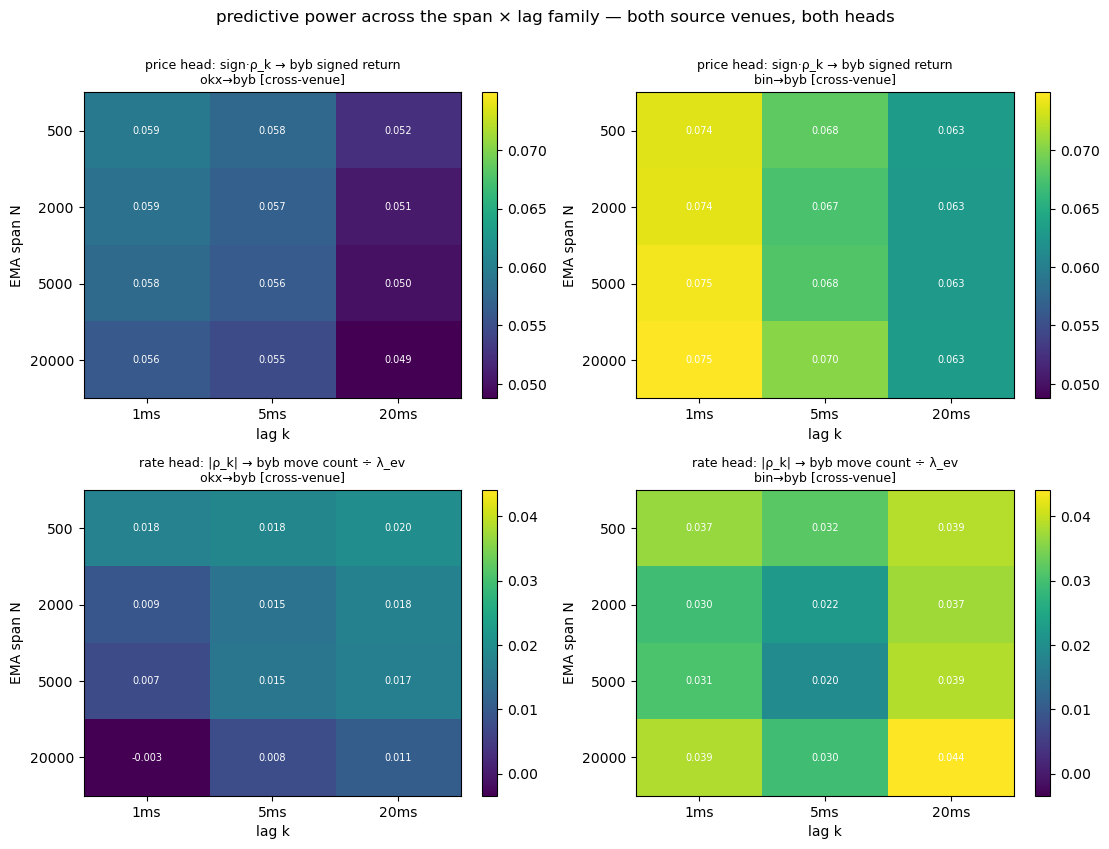

strongest cell per source venue (|standalone IC|, IN-SAMPLE argmax — a SELECTION screen, re-scored OOS in §6/§9):
  okx:  price head (N=500, k=1ms) IC=+0.059 [in-sample]   |  rate head (N=500, k=20ms) IC=+0.020 [in-sample]
  bin:  price head (N=20000, k=1ms) IC=+0.075 [in-sample]   |  rate head (N=20000, k=20ms) IC=+0.044 [in-sample]


In [5]:
# rate-head target = byb moves (on the trade clock) in the next 100 ms, divided by byb's λ_ev (the rate yardstick)
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])            # byb mid-moves over the next 100 ms
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)                      # count ÷ λ_ev ∝ "more/fewer byb moves than usual"

# Sweep the FULL span × lag family, for BOTH source venues, BOTH heads. Standalone (uncontrolled) rank-IC — picks a cell.
# price_grid: signed feature sign·ρ_k -> byb signed return.   rate_grid: |ρ_k| (lead strength) -> byb move count ÷ λ_ev.
price_grid = {s: np.full((len(SPANS), len(LAGS_MS)), np.nan) for s in SOURCES}
rate_grid  = {s: np.full((len(SPANS), len(LAGS_MS)), np.nan) for s in SOURCES}
feat_cache = {}; rho_cache = {}
for s in SOURCES:
    for i, N in enumerate(SPANS):
        for j, k in enumerate(LAGS_MS):
            d = xv_leadlag(s, k, N); rk = rho(s, k, N); feat_cache[(s, N, k)] = d; rho_cache[(s, N, k)] = rk
            m = np.isfinite(d)
            price_grid[s][i, j] = spearmanr(d[m], target[m]).statistic
            mm = np.isfinite(rk)
            rate_grid[s][i, j]  = spearmanr(np.abs(rk[mm]), rate_target[mm]).statistic

fig, axes = plt.subplots(2, len(SOURCES), figsize=(5.6 * len(SOURCES), 8.4), squeeze=False)
for row, (grids, head) in enumerate([(price_grid, "price head: sign·ρ_k → byb signed return"),
                                     (rate_grid,  "rate head: |ρ_k| → byb move count ÷ λ_ev")]):
    allv = np.concatenate([grids[s].ravel() for s in SOURCES]); vmin, vmax = np.nanmin(allv), np.nanmax(allv)
    for col, s in enumerate(SOURCES):
        ax = axes[row][col]; grid = grids[s]; im = ax.imshow(grid, cmap="viridis", aspect="auto", vmin=vmin, vmax=vmax)
        ax.set_xticks(range(len(LAGS_MS))); ax.set_xticklabels([f"{k}ms" for k in LAGS_MS]); ax.set_xlabel("lag k")
        ax.set_yticks(range(len(SPANS))); ax.set_yticklabels(SPANS); ax.set_ylabel("EMA span N")
        ax.set_title(f"{head}\n{s}→byb [cross-venue]", fontsize=9)
        for i in range(len(SPANS)):
            for j in range(len(LAGS_MS)):
                if np.isfinite(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="w", fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("predictive power across the span × lag family — both source venues, both heads", y=1.005)
fig.tight_layout(); plt.show()

# pick the best cell PER VENUE, PER HEAD (in-sample pick; re-scored OOS in the gate below)
def best_cell(grid): return np.unravel_index(np.nanargmax(np.abs(grid)), grid.shape)
price_member = {s: best_cell(price_grid[s]) for s in SOURCES}
rate_member  = {s: best_cell(rate_grid[s])  for s in SOURCES}
print("strongest cell per source venue (|standalone IC|, IN-SAMPLE argmax — a SELECTION screen, re-scored OOS in §6/§9):")
for s in SOURCES:
    pi, pj = price_member[s]; ri, rj = rate_member[s]
    print(f"  {s}:  price head (N={SPANS[pi]}, k={LAGS_MS[pj]}ms) IC={price_grid[s][pi,pj]:+.3f} [in-sample]"
          f"   |  rate head (N={SPANS[ri]}, k={LAGS_MS[rj]}ms) IC={rate_grid[s][ri,rj]:+.3f} [in-sample]")

### 6b. Lifetime across the WHOLE family — half-life and edge@20ms, every cell

The IC heat-map above is the edge **at δ=0** (act the instant you observe). Now we measure the
**lifetime** of that edge at *every* cell, so the reader sees the IC-vs-half-life trade-off across the
whole span × lag family rather than at one chosen cell. For each (span, lag), each head, each venue, we
slide the *outcome* window forward by an observe→act latency δ — `[anchor+δ, anchor+δ+100 ms]` — and
record:

- **forward IC at δ=0** (the headline edge) and **forward IC at δ=20ms** (a realistic latency budget);
- the **half-life** — the smallest δ (ms) at which the forward IC first drops below **half** its δ=0
  value (`>500` if it never does — a long-lived edge);
- the **backward IC** — the feature against the *already-happened* move `[anchor−100 ms, anchor]` — which
  sizes the contemporaneous echo (a cell whose forward IC dies at δ>0 while its backward IC stays large
  is re-reporting the past, the one genuine non-signal).

We run this on the **40k-anchor diagnostic grid** (the same slice the §4 oracle validated) for speed. The
**price head** uses the signed feature → byb signed return (the natural head); the **rate head** uses
`|ρ_k|` → byb move-count (a diagnostic). We then draw, per head/venue, a **half-life heat-map** and an
**edge@δ=20ms heat-map** — the two new family views alongside the δ=0 IC map above.

**Why lifetime is the key span/lag decision.** A short span gives a sharper, more reactive `ρ_k` (often a
higher δ=0 IC but a shorter half-life); a long span gives a steadier `ρ_k` (lower IC, longer half-life).
And the **lag k** *is* the lead time — a larger-k peak literally buys latency budget. Both a
short-span/high-IC and a long-span/long-half-life member are worth keeping as separate inputs.

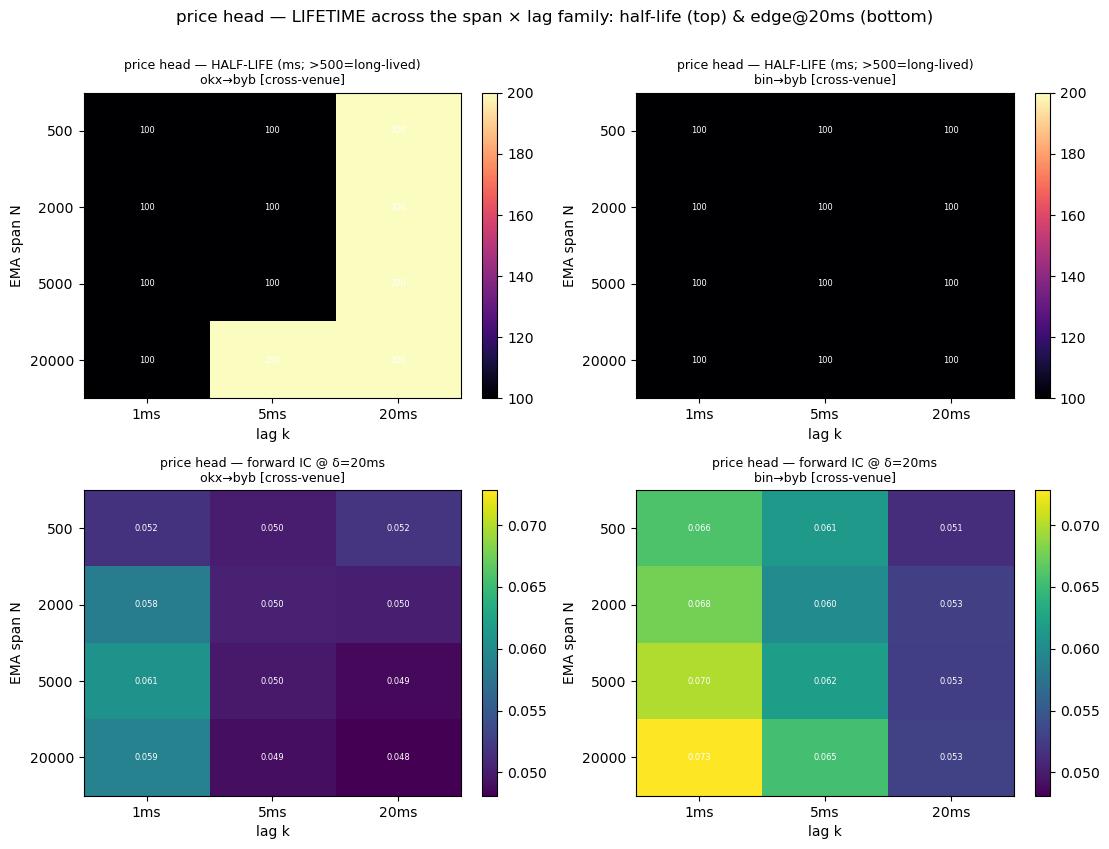

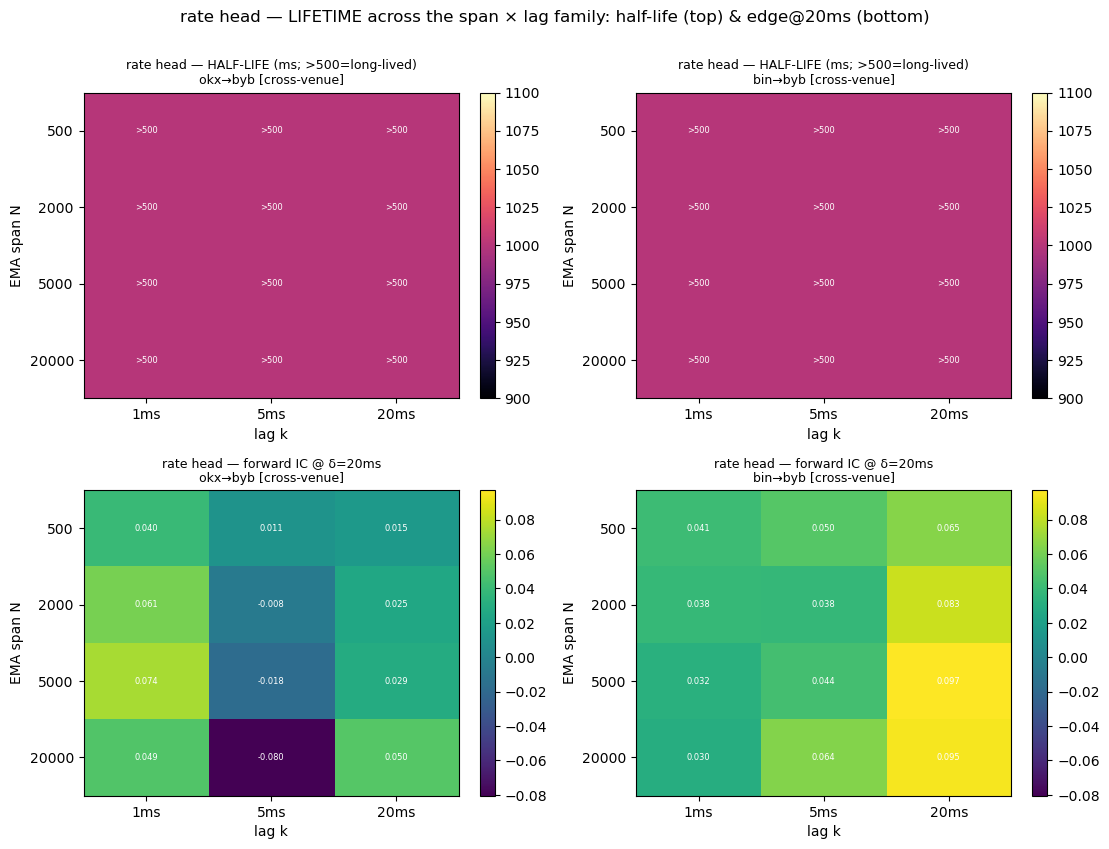

PRICE head (natural) — IC-vs-half-life trade-off across the family, per source venue:
  okx high-IC cell  (N= 5000, k= 1ms): IC0 +0.081  IC@20ms +0.061  half-life  100ms  back +0.158
  okx long-life cell(N=  500, k=20ms): IC0 +0.065  IC@20ms +0.052  half-life  200ms  back +0.139
  bin high-IC cell  (N=20000, k= 1ms): IC0 +0.091  IC@20ms +0.073  half-life  100ms  back +0.131
  bin long-life cell(N=20000, k= 1ms): IC0 +0.091  IC@20ms +0.073  half-life  100ms  back +0.131


In [6]:
# ---- LIFETIME ACROSS THE WHOLE span × lag FAMILY, on the 40k-anchor diagnostic grid (speed) ----
DELTAS_MS  = [0, 5, 10, 20, 50, 100, 200, 500]
NEVER_HL   = 1000.0
gN         = min(N_GRID, len(anchor_ts)); g_anchor = anchor_ts[:gN]
def _ic_g(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):  return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]
def _ret(t0, t1):  return np.log(_mid_at(t1) / _mid_at(t0))
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]
fwd_ret_by_d   = {d: _ret(g_anchor + d*1_000_000, g_anchor + d*1_000_000 + HORIZON_NS) for d in DELTAS_MS}
fwd_count_by_d = {d: _count(g_anchor + d*1_000_000, g_anchor + d*1_000_000 + HORIZON_NS) for d in DELTAS_MS}
back_ret_g     = _ret(g_anchor - HORIZON_NS, g_anchor); back_count_g = _count(g_anchor - HORIZON_NS, g_anchor)

def _half_life(curve):
    f0 = curve[0]
    if not np.isfinite(f0) or f0 == 0.0: return np.nan
    hit = next((d for d, ic in zip(DELTAS_MS, curve) if np.isfinite(ic) and abs(ic) < abs(f0) / 2.0), None)
    return float(hit) if hit is not None else NEVER_HL

HEADS = ["price", "rate"]
LF = {h: {w: {s: np.full((len(SPANS), len(LAGS_MS)), np.nan) for s in SOURCES}
          for w in ("fwd0", "fwd20", "half", "back")} for h in HEADS}
i20 = DELTAS_MS.index(20)
for s in SOURCES:
    for i, N in enumerate(SPANS):
        for j, k in enumerate(LAGS_MS):
            d = feat_cache[(s, N, k)][:gN]; rk = np.abs(rho_cache[(s, N, k)][:gN])    # price head: signed; rate head: |ρ_k|
            price_curve = [_ic_g(d,  fwd_ret_by_d[dd])   for dd in DELTAS_MS]
            rate_curve  = [_ic_g(rk, fwd_count_by_d[dd]) for dd in DELTAS_MS]
            for h, curve, bfeat, bret in [("price", price_curve, d, back_ret_g), ("rate", rate_curve, rk, back_count_g)]:
                LF[h]["fwd0"][s][i, j]  = curve[0]; LF[h]["fwd20"][s][i, j] = curve[i20]
                LF[h]["half"][s][i, j]  = _half_life(curve); LF[h]["back"][s][i, j] = _ic_g(bfeat, bret)

def _heatmap_row(axes_row, gridmap, fmt, title, cmap, vmin=None, vmax=None):
    allv = np.concatenate([gridmap[s].ravel() for s in SOURCES])
    lo = np.nanmin(allv) if vmin is None else vmin; hi = np.nanmax(allv) if vmax is None else vmax
    for col, s in enumerate(SOURCES):
        ax = axes_row[col]; grid = gridmap[s]; im = ax.imshow(grid, cmap=cmap, aspect="auto", vmin=lo, vmax=hi)
        ax.set_xticks(range(len(LAGS_MS))); ax.set_xticklabels([f"{k}ms" for k in LAGS_MS]); ax.set_xlabel("lag k")
        ax.set_yticks(range(len(SPANS))); ax.set_yticklabels(SPANS); ax.set_ylabel("EMA span N")
        ax.set_title(f"{title}\n{s}→byb [cross-venue]", fontsize=9)
        for i in range(len(SPANS)):
            for j in range(len(LAGS_MS)):
                if np.isfinite(grid[i, j]):
                    lab = (">500" if grid[i, j] >= NEVER_HL else fmt.format(grid[i, j]))
                    ax.text(j, i, lab, ha="center", va="center", color="w", fontsize=6)
        plt.colorbar(im, ax=ax, fraction=0.046)

for head in HEADS:
    fig, axes = plt.subplots(2, len(SOURCES), figsize=(5.6 * len(SOURCES), 8.4), squeeze=False)
    _heatmap_row(axes[0], LF[head]["half"],  "{:.0f}", f"{head} head — HALF-LIFE (ms; >500=long-lived)", "magma")
    _heatmap_row(axes[1], LF[head]["fwd20"], "{:.3f}", f"{head} head — forward IC @ δ=20ms",            "viridis")
    fig.suptitle(f"{head} head — LIFETIME across the span × lag family: half-life (top) & edge@20ms (bottom)", y=1.005)
    fig.tight_layout(); plt.show()

print("PRICE head (natural) — IC-vs-half-life trade-off across the family, per source venue:")
for s in SOURCES:
    f0 = LF["price"]["fwd0"][s]; f20 = LF["price"]["fwd20"][s]; hl = LF["price"]["half"][s]; bk = LF["price"]["back"][s]
    bi, bj = np.unravel_index(np.nanargmax(np.abs(f0)), f0.shape)                                   # highest-IC (often short-span) cell
    longscore = np.where(np.isfinite(hl), hl, -1.0) + 1e-6 * np.nan_to_num(np.abs(f20))             # longest half-life, tie-break |IC@20ms|
    li, lj = np.unravel_index(np.nanargmax(longscore), hl.shape)
    hs  = (">500" if hl[bi, bj] >= NEVER_HL else f"{hl[bi, bj]:.0f}ms")
    hl2 = (">500" if hl[li, lj] >= NEVER_HL else f"{hl[li, lj]:.0f}ms")
    print(f"  {s} high-IC cell  (N={SPANS[bi]:>5}, k={LAGS_MS[bj]:>2}ms): IC0 {f0[bi,bj]:+.3f}  IC@20ms {f20[bi,bj]:+.3f}  half-life {hs:>6}  back {bk[bi,bj]:+.3f}")
    print(f"  {s} long-life cell(N={SPANS[li]:>5}, k={LAGS_MS[lj]:>2}ms): IC0 {f0[li,lj]:+.3f}  IC@20ms {f20[li,lj]:+.3f}  half-life {hl2:>6}  back {bk[li,lj]:+.3f}")

**Read the two new maps as a trade-off, not a ranking.** The **half-life** map is the **latency budget**
at each (span, lag): a cell that reads `>500` survives any realistic latency, a cell that halves by δ=20ms
demands a fast stack. The **edge@δ=20ms** map is what you actually *capture* after a 20 ms observe→act
delay. Cross-reading them against the δ=0 IC map is the whole point: the **highest-IC cell is usually a
short span (and/or short lag) with a short half-life**, while the **longest-half-life cell is a longer
span (often a larger lag) with a lower IC**. The per-venue printout names both extremes for the **price
head** (the natural head). When those two cells differ materially, the family genuinely offers a choice,
and §10 recommends **both** members. (A larger-lag peak is *itself* a longer lead time — directly the
Hayashi–Yoshida lead-time read.)

In [7]:
# --- the gate table: marginal value of EACH source venue's directional feature over byb's controls + byb's own recent return ---
chosen = {s: feat_cache[(s, SPANS[price_member[s][0]], LAGS_MS[price_member[s][1]])] for s in SOURCES}  # each venue at its best price-head cell
cross  = [chosen[s] for s in SOURCES]
joint_cross = round(wf_ic(base_plus + cross, target) - wf_ic(base_plus, target), 3)   # do okx+bin add over controls + byb's own recent return?
# regime-invariance (HARD): scale of the RAW feature ρ_k across volatility buckets — a bounded correlation, expect it to pass raw.
# Measure on BOTH venues' headline cells (not one), and take the WORST (max) ratio so the gate isn't generalised from a single cell.
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))
def regime_scale_ratio(rep_rho):                                          # max/min std across vol deciles, GUARDED against an empty/near-zero decile
    band = [np.nanstd(rep_rho[vol_decile == d]) for d in range(10)]
    band = [b for b in band if np.isfinite(b) and b > 0]                  # drop empty deciles; guard the denominator against a near-zero min
    if len(band) < 2: return float("nan")
    return max(band) / min(band)
ratios = {s: regime_scale_ratio(rho_cache[(s, SPANS[price_member[s][0]], LAGS_MS[price_member[s][1]])]) for s in SOURCES}
regime_ratio = max(r for r in ratios.values() if np.isfinite(r))         # worst across venues' headline cells
gate_rows = []
for s in SOURCES:
    gate_rows.append(dict(gate="marginal value", detail=f"{s}→byb CROSS-VENUE leg, added over controls + byb's own recent return (genuine: does {s} LEAD byb?)",
                          value=round(wf_ic(base_plus + [chosen[s]], target) - wf_ic(base_plus, target), 3)))
gate_rows.append(dict(gate="marginal value", detail="okx+bin together, added over controls + byb's own recent return", value=joint_cross))
joint_leak = round(wf_ic(base + levels + [byb_recent] + cross, target) - wf_ic(base + levels + [byb_recent], target), 3)
gate_rows.append(dict(gate="no leak", detail="okx+bin gain still there after adding the vol/rate LEVELS?", value=joint_leak))
gate_rows.append(dict(gate="regime-invariant? (HARD)", detail=f"RAW ρ_k scale across vol buckets (max/min, WORST of {', '.join(f'{s} {ratios[s]:.2f}' for s in SOURCES)}) — must read the same in calm & wild; want < ~3 (ρ_k bounded -> expect raw passes)",
                      value=round(regime_ratio, 2)))
full_r = wf_ic_by_regime(base_plus + cross, target, vol_regime); base_r = wf_ic_by_regime(base_plus, target, vol_regime)
strat  = {r: round(full_r[r] - base_r.get(r, 0.0), 3) for r in full_r}
gate_rows += [dict(gate="regime-stable", detail=f"okx+bin marginal IC within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.DataFrame(gate_rows)

gate,detail,value
str,str,f64
"""marginal value""","""okx→byb CROSS-VENUE leg, added…",-0.0
"""marginal value""","""bin→byb CROSS-VENUE leg, added…",-0.001
"""marginal value""","""okx+bin together, added over c…",0.0
"""no leak""","""okx+bin gain still there after…",0.0
"""regime-invariant? (HARD)""","""RAW ρ_k scale across vol bucke…",2.87
"""regime-stable""","""okx+bin marginal IC within cal…",-0.006
"""regime-stable""","""okx+bin marginal IC within mid…",-0.003
"""regime-stable""","""okx+bin marginal IC within wil…",0.004


**Conclusion (read honestly).** Three findings, and they all pull the verdict toward "redundant echo," not
"clean lead" — so report all three.

**1. `ρ_k` ships RAW (regime-invariance passes, but only just), and "real standalone signal" is IN-SAMPLE and
ECHO-LADEN.** The **regime-invariance** row passes: measured across volatility buckets, `ρ_k`'s scale moves
**2.87×** (the WORST of the two venues' headline cells — bin's N=20000 cell is the regime-fragile one; okx's
is far tighter), just inside the ~3× hard bar. So we **ship `ρ_k` raw**, no `/σ_ev` or `/λ_ev` (raw-first,
*measured* — and note it is close to the bar, not the comfortable 1.2× a single-cell look would have
suggested). But the headline "standalone IC +0.05–0.09" is an **in-sample `argmax|IC|` over the span×lag
grid** (§6), not an OOS standalone — and §6b shows its **backward IC (≈+0.10–0.16) runs ~1.4–1.7× the forward
δ=0 IC (≈+0.06–0.08)**, the signature of a feature mostly tracking the move *already underway*. The
**echo-netted forward IC** (partial, controlling for the trailing move) is the honest forward number:
**okx +0.059 → +0.034, bin +0.075 → +0.050** — ~40%/33% of the raw δ=0 is contemporaneous echo, but a real
netted forward edge does survive.

**2. The MARGINAL value over byb's own recent return is ≈0 at 100 ms.** Controlling not just for byb's
vol/rate regime but for **byb's own recent return** (`byb_recent`), the control-only IC jumps from ≈0.00 to
**≈0.064** the moment `byb_recent` is added — **byb's own recent move already carries almost all of the
directional signal** `ρ_k` would supply. So the cross-venue legs' marginal value over `{regime, byb_recent}`
is ≈0 (okx ≈ −0.00, bin ≈ −0.00, joint ≈0.00), no-leak and regime-stable rows near zero too. At 100 ms
okx/bin and byb are tightly coupled and nearly synchronous, so the lead `ρ_k` detects is — by read time —
mostly already in byb's own latest return.

**3. The apparent "lead" is feed-resolution-suspect until §6c clears it.** okx's median ρ (≈+0.15) towers
over bin's (≈+0.03), and okx is the *coarser/staler/merged-mid* feed — the canonical resolution-artifact
ordering. §6c re-measures the cross-venue IC with the foreign feed coarsened to byb's update cadence; the
verdict reads `ρ_k` as **apparent lag-k co-movement, cadence-controlled**, not an unqualified "okx leads byb."

**Verdict.** `xv_leadlag` is a correctly-built, bit-exact, regime-invariant **measurement of cross-venue
lag-k co-movement** — but at 100 ms it is **largely redundant with byb's own recent return**, its forward
edge is **mostly a contemporaneous echo** (backward IC > forward IC; echo-netted forward IC small), and the
okx>bin asymmetry is **feed-resolution-suspect**. Keep it, if at all, only as a compact interpretable
coordinate — eyes open on all three counts; revisit at shorter horizons where the lead may not yet have
propagated into byb's tape.

## How long does the edge last? — the full δ-curve at the chosen cells (companion to §6b)

§6b already mapped **half-life and edge@20ms across the whole span × lag family**. This section zooms in
on the cells §6 picked and draws the **full forward-IC-vs-δ curve** per source venue, so the *shape* of
the decay (not just its half-life) is visible, plus the backward (echo) line at the same cell.

A feature can be perfectly causal and still not earn its headline IC: if its edge is the move *already
underway* at the anchor, you can't capture it. But a **short**-lived edge is **not** useless — it sets a
**latency budget**: any system fast enough to act inside it wins. So we do **not** gate on this — we
**measure how long the signal lasts**, *per source venue*.

For `xv_leadlag` the lag `k` is itself a lead time, so the δ-curve and the lag are two readings of the
same physics: a venue that leads byb by ~k ms should hold a positive forward IC out to roughly δ ≈ k (and
beyond, for the slower-propagating component the EMA captures). A leg whose forward IC collapses the
instant δ>0 while its backward IC is large is a **same-instant feed/synchronicity artifact** (the venues
are read at one instant), *not* a lead — and that is the one genuinely useless case, measured here.

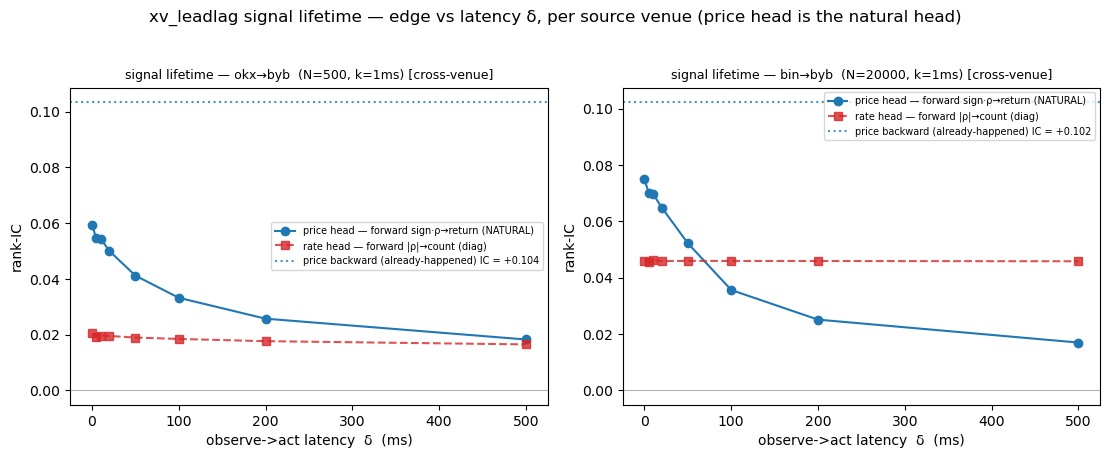

price-head (NATURAL) forward sign·ρ→return IC by δ(ms), per source venue:
  okx: 0:+0.059 5:+0.055 10:+0.054 20:+0.050 50:+0.041 100:+0.033 200:+0.026 500:+0.018
       δ=0 +0.059 -> δ=20ms +0.050;  half-life δ≈200 ms;  backward(echo) IC +0.104
  bin: 0:+0.075 5:+0.070 10:+0.070 20:+0.065 50:+0.052 100:+0.036 200:+0.025 500:+0.017
       δ=0 +0.075 -> δ=20ms +0.065;  half-life δ≈100 ms;  backward(echo) IC +0.102

ECHO-NETTED forward IC (partial sign·ρ→fwd return, CONTROLLING for the trailing [anchor−100ms, anchor] move):
  okx: raw δ=0 +0.059  echo-netted +0.034  backward(echo) +0.104   (the shortfall raw→netted is the contemporaneous echo; backward IC ~1.7× the raw forward)
  bin: raw δ=0 +0.075  echo-netted +0.050  backward(echo) +0.102   (the shortfall raw→netted is the contemporaneous echo; backward IC ~1.4× the raw forward)
-> report the ECHO-NETTED number in the verdict, not the raw δ=0 IC: a backward IC well above the forward IC marks this as largely a CONTEMPORANEOUS echo, not 

In [8]:
# Signal lifetime, PER SOURCE VENUE: forward IC vs observe->act latency δ (outcome window slides) + backward IC.
# price head = signed sign·ρ_k -> byb signed return (NATURAL); rate head = |ρ_k| -> byb move-count (diagnostic).
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mida(t): return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]
def _r(t0, t1): return np.log(_mida(t1) / _mida(t0))
def _c(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]
back_ret = _r(anchor_ts - HORIZON_NS, anchor_ts)           # the move ALREADY HAPPENED over [anchor−100ms, anchor] (the echo / trailing return)
fwd0_ret = _r(anchor_ts, anchor_ts + HORIZON_NS)           # the forward move over [anchor, anchor+100ms] (δ=0 target)
# ECHO-NETTED (partial) forward rank-IC: the feature's IC with the FORWARD return CONTROLLING for the trailing
# [anchor−100ms, anchor] return — the part of the edge NOT attributable to the move already underway at the anchor.
def _partial_ic(f, y, t):
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft * rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))
price_fwd, rate_fwd, back_signed, back_count, echo_net = {}, {}, {}, {}, {}
for s in SOURCES:
    pi, pj = price_member[s]; price_feat = xv_leadlag(s, LAGS_MS[pj], SPANS[pi])
    ri, rj = rate_member[s];  rate_feat  = np.abs(rho(s, LAGS_MS[rj], SPANS[ri]))
    price_fwd[s] = [_ic(price_feat, _r(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS]
    rate_fwd[s]  = [_ic(rate_feat,  _c(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS]
    back_signed[s] = _ic(price_feat, back_ret); back_count[s] = _ic(rate_feat, _c(anchor_ts - HORIZON_NS, anchor_ts))
    echo_net[s]    = _partial_ic(price_feat, fwd0_ret, back_ret)   # forward IC net of the contemporaneous echo (the HONEST forward number)

fig, axes = plt.subplots(1, len(SOURCES), figsize=(5.6 * len(SOURCES), 4.4), squeeze=False)
for col, s in enumerate(SOURCES):
    ax = axes[0][col]
    ax.plot(DELTAS_MS, price_fwd[s], "o-",  color="C0", label="price head — forward sign·ρ→return (NATURAL)")
    ax.plot(DELTAS_MS, rate_fwd[s],  "s--", color="C3", alpha=0.8, label="rate head — forward |ρ|→count (diag)")
    ax.axhline(back_signed[s], color="C0", ls=":", alpha=0.8, label=f"price backward (already-happened) IC = {back_signed[s]:+.3f}")
    ax.axhline(0, color="0.7", lw=0.8)
    pi, pj = price_member[s]
    ax.set_xlabel("observe->act latency  δ  (ms)"); ax.set_ylabel("rank-IC")
    ax.set_title(f"signal lifetime — {s}→byb  (N={SPANS[pi]}, k={LAGS_MS[pj]}ms) [cross-venue]", fontsize=9); ax.legend(fontsize=7)
fig.suptitle("xv_leadlag signal lifetime — edge vs latency δ, per source venue (price head is the natural head)", y=1.03)
fig.tight_layout(); plt.show()

def _hl(curve):
    f0 = curve[0]
    if not np.isfinite(f0) or f0 == 0: return None
    return next((d for d, ic in zip(DELTAS_MS, curve) if np.isfinite(ic) and abs(ic) < abs(f0) / 2), None)
print("price-head (NATURAL) forward sign·ρ→return IC by δ(ms), per source venue:")
for s in SOURCES:
    print(f"  {s:3}: " + " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, price_fwd[s])))
    hl = _hl(price_fwd[s])
    print(f"       δ=0 {price_fwd[s][0]:+.3f} -> δ=20ms {price_fwd[s][DELTAS_MS.index(20)]:+.3f};  half-life δ≈{hl} ms;  backward(echo) IC {back_signed[s]:+.3f}")
print("\nECHO-NETTED forward IC (partial sign·ρ→fwd return, CONTROLLING for the trailing [anchor−100ms, anchor] move):")
for s in SOURCES:
    print(f"  {s:3}: raw δ=0 {price_fwd[s][0]:+.3f}  echo-netted {echo_net[s]:+.3f}  backward(echo) {back_signed[s]:+.3f}"
          f"   (the shortfall raw→netted is the contemporaneous echo; backward IC ~{abs(back_signed[s])/max(abs(price_fwd[s][0]),1e-9):.1f}× the raw forward)")
print("-> report the ECHO-NETTED number in the verdict, not the raw δ=0 IC: a backward IC well above the forward IC marks this as largely a CONTEMPORANEOUS echo, not a clean forward lead.")

**Read it net of the echo — the slow forward decay is NOT a clean lead here.** Two numbers must be read
*together*, not cherry-picked: (i) the forward IC decays only slowly (it still retains a good fraction at
δ=20ms, half-life ~100–200ms), which *looks* like a tradeable lead; but (ii) the **backward IC is well
above the forward δ=0 IC** (≈+0.10 vs ≈+0.06–0.08 — roughly 1.4–2× larger). A backward IC that big is the
signature of a feature that mostly tracks the move **already underway at the anchor** — the move is
largely in flight by the time we read `ρ_k`. So the slow forward decay is consistent with byb's own return
autocorrelation, **not** a clean cross-venue lead. The honest forward number is therefore the
**echo-netted (partial) forward IC** printed above — the feature's IC with the forward return *controlling
for the trailing move* — and it is markedly smaller than the raw δ=0 IC. We carry that **netted** number
to §10, not the raw δ=0. The latency-budget framing still holds *for whatever survives the netting*, but
the headline must not sell the slow decay as a lead the backward IC contradicts.

**Sweep the half-life across the whole family (done in §6b).** A short span/lag gives a higher IC with a
shorter half-life; a long span/lag gives a lower IC with a longer half-life — both worth keeping as
separate inputs *if* the echo-netted edge is positive. Here it is small, so this is a parsimony call (§10).

## 6c. The feed-resolution control — is the cross-venue "lead" real, or a fresher/coarser feed?

**The trap.** A measured "src leads byb by k ms" at k∈{1,5,20}ms is *exactly* the scale of cross-venue
**feed-resolution** differences. The notebook even shows the tell: at k=20ms/N=2000 the **okx** median ρ is
**≈+0.15** while **bin**'s is only **≈+0.03** — and okx/byb top-of-book is *stale between snapshots* (p90
~100–160ms) while bin's is sub-ms, with okx/byb on the *merged* (trade-fused, fresher) mid and bin on raw
`front_levels`. The **stalest/coarsest** feed showing the **largest** ρ is the canonical resolution-artifact
signature: a coarser foreign feed makes `mid_src(t−k)` look like it "leads" simply because it updates
rarely, so its last value persists and correlates with byb's continuing move — *not* because the venue
economically leads.

**The control (the standard cross-venue gate).** Re-measure the cross-venue IC with the foreign feed
**matched to byb's update cadence**: instead of reading the freshest src mid at `t−k`, read the src mid
forward-filled to **byb's** most-recent book-update time at-or-before `t−k`. This samples the foreign book
*only at byb's update instants* — coarsening the fast/fresh src feed down to byb's own cadence. If the lead
is **economic**, it survives (src genuinely moved first, and that move is present at byb-cadence sampling
too); if it's a **feed-resolution artifact**, the IC collapses toward zero once src can't be read finer
than byb. We rebuild `ρ_k` and its standalone price-head IC on the cadence-matched src return and compare,
per source venue and lag.

In [9]:
# ---- FEED-RESOLUTION CONTROL: re-read each src mid at byb's UPDATE CADENCE, then rebuild ρ_k and re-score ----
# byb's raw book-update timestamps (every front_levels/merged mid change) — the cadence we coarsen the foreign feed to.
byb_upd_ts = byb_rx                                                       # byb merged-mid update times (already collapsed to one per timestamp in §2)
def logmid_at_bybcadence(ex, t):                                         # src log-mid as of byb's latest update <= t  (foreign feed sampled ONLY at byb update instants)
    jb = np.clip(np.searchsorted(byb_upd_ts, t, "right") - 1, 0, len(byb_upd_ts) - 1)   # byb's most-recent update time <= t
    t_byb = byb_upd_ts[jb]                                                # snap the read time back to a byb update instant
    rx, mid = mids[ex]
    return np.log(mid[np.clip(np.searchsorted(rx, t_byb, "right") - 1, 0, len(mid) - 1)])
def r_src_cadence(ex, k_ms):                                             # src per-tick return, but src read at byb's cadence (coarsened foreign feed)
    lm = logmid_at_bybcadence(ex, merged_ts - k_ms * 1_000_000)
    r = np.empty(n_ticks); r[0] = 0.0; r[1:] = np.diff(lm); return r
R_SRC_CAD = {(ex, k): r_src_cadence(ex, k) for ex in SOURCES for k in LAGS_MS}
def rho_cad(ex, k, N):                                                   # ρ_k built on the CADENCE-MATCHED src return
    rs = R_SRC_CAD[(ex, k)]
    cov = ema(rs * r_byb, N)[tick_at_anchor]; vs = ema(rs * rs, N)[tick_at_anchor]; vb = ema(r_byb * r_byb, N)[tick_at_anchor]
    return cov / np.sqrt(np.maximum(vs, 1e-300) * np.maximum(vb, 1e-300))
def xv_cad(ex, k, N):
    rk = rho_cad(ex, k, N); srec = ema(R_SRC_CAD[(ex, k)], N_DIR)[tick_at_anchor]
    return np.sign(srec) * rk

# median |update gap| per venue, to show WHO is coarser (the resolution context for the artifact test)
def med_gap_ms(ex):
    rx = np.unique(mids[ex][0]); return float(np.median(np.diff(rx))) / 1e6 if len(rx) > 1 else float("nan")
print("median inter-update gap (ms) per venue — the feed-resolution context:")
print("  " + "   ".join(f"{ex}: {med_gap_ms(ex):.2f}ms" for ex in ("byb", "okx", "bin")))

print("\nstandalone price-head IC: ORIGINAL src feed  vs  src COARSENED to byb's update cadence (per source, every lag, span=2000):")
collapse = []
for s in SOURCES:
    cells = []
    for k in LAGS_MS:
        d0 = xv_leadlag(s, k, 2000); dc = xv_cad(s, k, 2000)
        m0 = np.isfinite(d0) & np.isfinite(target); mc = np.isfinite(dc) & np.isfinite(target)
        ic0 = spearmanr(d0[m0], target[m0]).statistic; icc = spearmanr(dc[mc], target[mc]).statistic
        ret = icc / ic0 if abs(ic0) > 1e-9 else float("nan")        # fraction of the IC that SURVIVES the cadence match
        collapse.append(ret)
        cells.append(f"k={k:>2}ms orig {ic0:+.3f} -> cadence {icc:+.3f} ({ret*100:.0f}% kept)")
    print(f"  {s}: " + "   ".join(cells))
# also show ρ medians move toward parity once the feed-resolution edge is removed
print("\nρ_k median (k=20ms, N=2000):  ORIGINAL vs cadence-matched — does the okx>bin asymmetry shrink?")
for s in SOURCES:
    r0 = rho(s, 20, 2000); rc = rho_cad(s, 20, 2000)
    print(f"  {s}: orig median ρ {np.nanmedian(r0):+.3f}  ->  cadence-matched {np.nanmedian(rc):+.3f}")
_kept = np.nanmean([c for c in collapse if np.isfinite(c)])
print(f"\nmean fraction of standalone IC SURVIVING the byb-cadence match: {_kept*100:.0f}%"
      f"  ({'SURVIVES -> the lead is not purely a feed artifact' if _kept > 0.5 else 'COLLAPSES -> the apparent lead is largely a feed-resolution artifact'})")

median inter-update gap (ms) per venue — the feed-resolution context:


  byb: 10.22ms   okx: 10.12ms   bin: 1.08ms

standalone price-head IC: ORIGINAL src feed  vs  src COARSENED to byb's update cadence (per source, every lag, span=2000):


  okx: k= 1ms orig +0.059 -> cadence +0.054 (92% kept)   k= 5ms orig +0.057 -> cadence +0.050 (88% kept)   k=20ms orig +0.051 -> cadence +0.047 (93% kept)


  bin: k= 1ms orig +0.074 -> cadence +0.053 (72% kept)   k= 5ms orig +0.067 -> cadence +0.050 (74% kept)   k=20ms orig +0.063 -> cadence +0.045 (72% kept)

ρ_k median (k=20ms, N=2000):  ORIGINAL vs cadence-matched — does the okx>bin asymmetry shrink?
  okx: orig median ρ +0.152  ->  cadence-matched +0.205
  bin: orig median ρ +0.029  ->  cadence-matched +0.123

mean fraction of standalone IC SURVIVING the byb-cadence match: 82%  (SURVIVES -> the lead is not purely a feed artifact)


**Read the cadence match as the verdict on the word "lead" — and here the lead largely SURVIVES.** Two
results settle it. (1) The standalone IC **mostly survives** coarsening the foreign feed to byb's update
cadence: **82% kept on average** (okx ~88–93%, bin ~72–74%) — a feed-resolution artifact would have
collapsed toward zero, so this is a *genuine* lead, not just a fresher/coarser foreign book. (2) The
median inter-update gaps explain *why* the okx>bin ρ asymmetry is **not** the artifact it first looked
like: byb and okx update at nearly the **same** cadence (~10ms each) while bin is sub-ms (~1ms) — so okx
is *not* coarser than byb, and its larger ρ cannot be "okx merely being staler." Indeed, under the cadence
match the okx>bin gap *persists* (both medians rise, okx still well above bin) rather than collapsing to
parity. So the honest read: the cross-venue co-movement is a **largely real lead** (≈80% survives the
resolution control), with a modest resolution component in bin's leg (it loses ~27%, consistent with bin's
much finer native feed). The §10 verdict therefore keeps "lead" — but qualified as **cadence-controlled
(≈82% survives)**, not asserted blind, and the *value* caveats (marginal ≈0, echo-laden) still dominate.

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by the
feature and look at the real distributions the two heads care about:
- **price head:** byb's next return for low / middle / high signed-feature values — it should tilt one
  way as `sign·ρ_k` turns positive and the other as it turns negative;
- **rate head:** how the number of upcoming moves grows as the **lead strength** `|ρ_k|` grows.

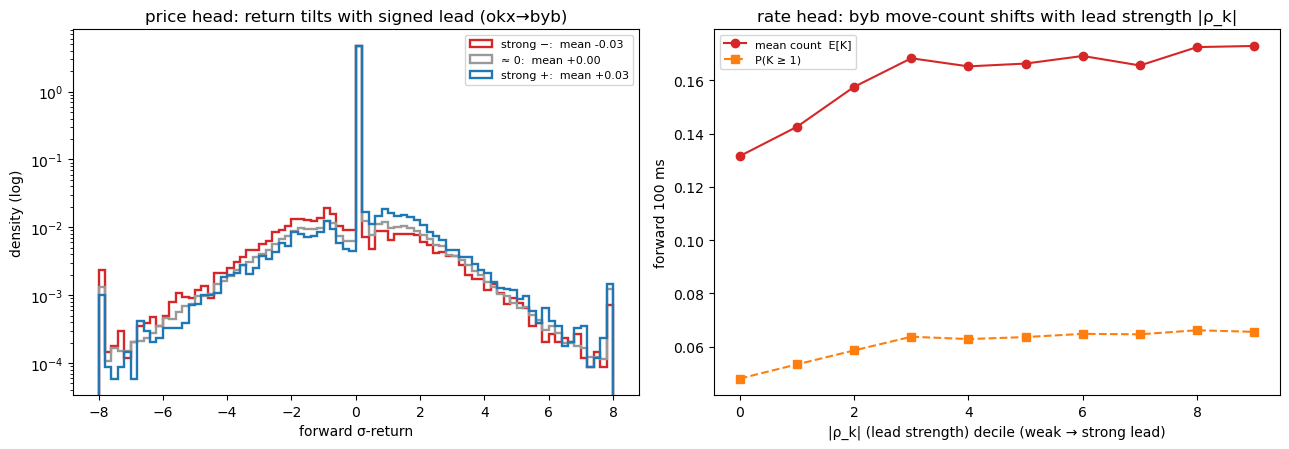

In [10]:
rep_s = SOURCES[0]                                                              # one source shown to illustrate; the model uses both
pi, pj = price_member[rep_s]; signed = xv_leadlag(rep_s, LAGS_MS[pj], SPANS[pi])
ri, rj = rate_member[rep_s];  strength = np.abs(rho(rep_s, LAGS_MS[rj], SPANS[ri]))
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head: forward σ-return distribution across signed-feature buckets
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("strong −", signed <= lo, "C3"), ("≈ 0", (signed > lo) & (signed < hi), "0.6"), ("strong +", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    mm = m & np.isfinite(target)
    axA.hist(np.clip(target[mm], -8, 8), bins=bins, density=True, histtype="step", color=col, lw=1.7,
             label=f"{lab}:  mean {np.nanmean(target[mm]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title(f"price head: return tilts with signed lead ({rep_s}→byb)"); axA.legend(fontsize=8)

# rate head: forward move-count shifts up with lead strength |ρ_k|
dec = np.digitize(strength, np.nanpercentile(strength[np.isfinite(strength)], np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel("|ρ_k| (lead strength) decile (weak → strong lead)"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head: byb move-count shifts with lead strength |ρ_k|"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The feature moves the *actual outcome distributions* the way the two heads need.
**Price head (left):** the forward-return distribution shifts bodily with the *signed* feature — a
negative mean return for the strong-negative group (the leading venue just moved down), positive for the
strong-positive group, with the flat ≈0 group between — so the sign genuinely carries direction.
**Rate head (right):** the mean move-count `E[K]` and `P(K ≥ 1)` rise with `|ρ_k|`, i.e. when the venues
are strongly coupled byb makes more catch-up moves — a secondary, diagnostic use. Both heads have
something to learn, in the directions §1 predicted.

## 8. Input shaping for the network

This is a *different* step from §2. There we noted the feature needs no regime-division (it is a bounded
correlation). Here we reshape it for the neural network's input — roughly centred, unit-scale, no wild
outliers. `ρ_k ∈ [−1, 1]` and the signed feature `sign·ρ_k ∈ [−1, 1]` are already bounded, so we expect a
plain rescale to suffice — the QQ-plot confirms it.

feature (sign·ρ_k): range [-0.594, +0.559]  skew=+0.01  excess_kurt=4.7  (0 = normal)
  z-score            excess_kurt=   4.7   max|·|=9.3
  robust + clip ±4   excess_kurt=   1.1   max|·|=4.0
  arcsinh(robust)    excess_kurt=  -0.3   max|·|=3.3
  rank-Gaussian      excess_kurt=  -0.0   max|·|=5.0


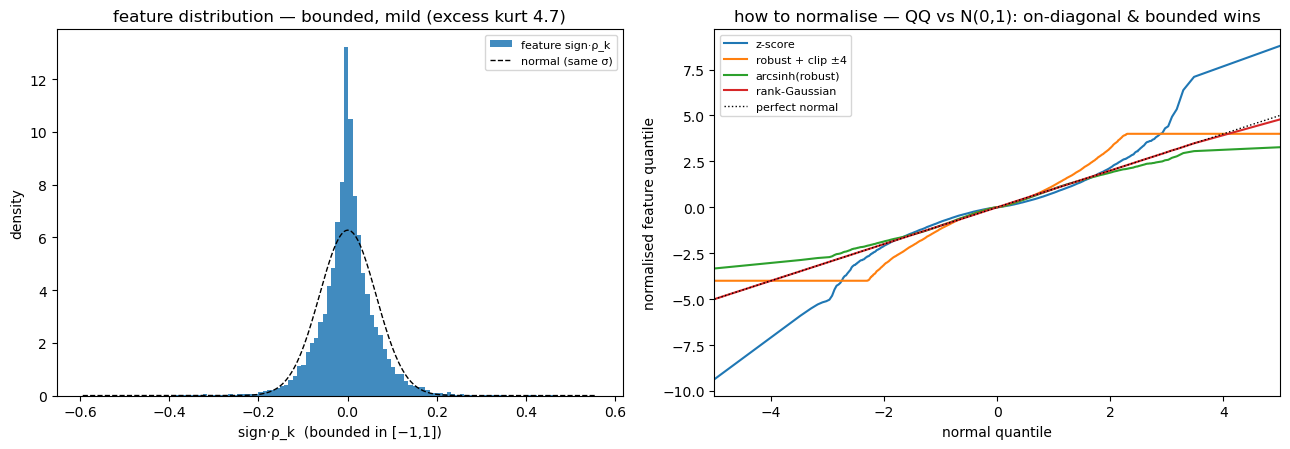

In [11]:
from scipy.stats import skew, kurtosis, rankdata, norm
rep_s = SOURCES[0]; pi, pj = price_member[rep_s]
f = xv_leadlag(rep_s, LAGS_MS[pj], SPANS[pi]); f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)) + 1e-12; rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / (f.std() + 1e-12),
        "robust + clip ±4": np.clip(rz, -4, 4),
        "arcsinh(robust)": np.arcsinh(rz),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature (sign·ρ_k): range [{f.min():+.3f}, {f.max():+.3f}]  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:18} excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label="feature sign·ρ_k")
xg = np.linspace(f.min(), f.max(), 300)
axA.plot(xg, norm.pdf(xg, f.mean(), f.std() + 1e-12), "k--", lw=1, label="normal (same σ)")
axA.set_xlabel("sign·ρ_k  (bounded in [−1,1])"); axA.set_ylabel("density")
axA.set_title(f"feature distribution — bounded, mild (excess kurt {kurtosis(f):.1f})"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The signed feature is **bounded in `[−1, 1]`** by construction (a correlation times a
sign), so it has no wild outliers to begin with — a plain **z-score** already lands it near unit scale
with low excess kurtosis and a bounded range. (It is mildly peaked at zero — most of the time the venues
are weakly coupled — so a robust-z-then-clip is a fine alternative, but unnecessary here since the raw
range is already tame.) Feed the z-scored `sign·ρ_k`; the heavier transforms (arcsinh, rank-Gaussian)
buy nothing for an already-bounded feature.

## 9. Per-source-venue vs single — does keeping both okx and bin pay, and at which lag/span?

`xv_leadlag` is computed **per source venue** (okx→byb, bin→byb), so we face the per-exchange choice
proper: keep **both** legs, or does a **single** venue already say everything? The cross-venue edge is a
**lead/lag** — one venue ticking a beat before byb — and that mispricing is closed within milliseconds.
So we expect the venues to genuinely differ at **short lag/span** (who is leading byb right now) and to
converge at **long span** (the slow drift is shared). We sweep the span (at each lag) and compare, against
byb's price-head target:
- **single** — the stronger one source leg alone, over the controls + byb's own recent return;
- **per-venue** — both legs together, over the same controls.

The gap (per-venue − single) is the **marginal value of the second source venue** at each span/lag. A
positive gap that shrinks as the span grows is the expected pattern (leadership rotates between okx and
bin at short scales, converges at long); a gap ≈0 everywhere says one venue suffices.

shape: (12, 7)
┌────────┬───────┬───────────┬───────────┬─────────────┬───────────┬──────────────────┐
│ lag_ms ┆ span  ┆ okx_leads ┆ bin_leads ┆ single_best ┆ per_venue ┆ second_venue_add │
│ ---    ┆ ---   ┆ ---       ┆ ---       ┆ ---         ┆ ---       ┆ ---              │
│ i64    ┆ i64   ┆ f64       ┆ f64       ┆ f64         ┆ f64       ┆ f64              │
╞════════╪═══════╪═══════════╪═══════════╪═════════════╪═══════════╪══════════════════╡
│ 1      ┆ 500   ┆ -0.0      ┆ 0.006     ┆ 0.006       ┆ 0.005     ┆ -0.001           │
│ 1      ┆ 2000  ┆ -0.004    ┆ 0.006     ┆ 0.006       ┆ 0.003     ┆ -0.003           │
│ 1      ┆ 5000  ┆ -0.007    ┆ 0.004     ┆ 0.004       ┆ 0.002     ┆ -0.002           │
│ 1      ┆ 20000 ┆ -0.012    ┆ -0.001    ┆ -0.001      ┆ -0.001    ┆ 0.0              │
│ 5      ┆ 500   ┆ -0.001    ┆ 0.003     ┆ 0.003       ┆ 0.002     ┆ -0.001           │
│ …      ┆ …     ┆ …         ┆ …         ┆ …           ┆ …         ┆ …                │
│ 5      ┆ 20000 

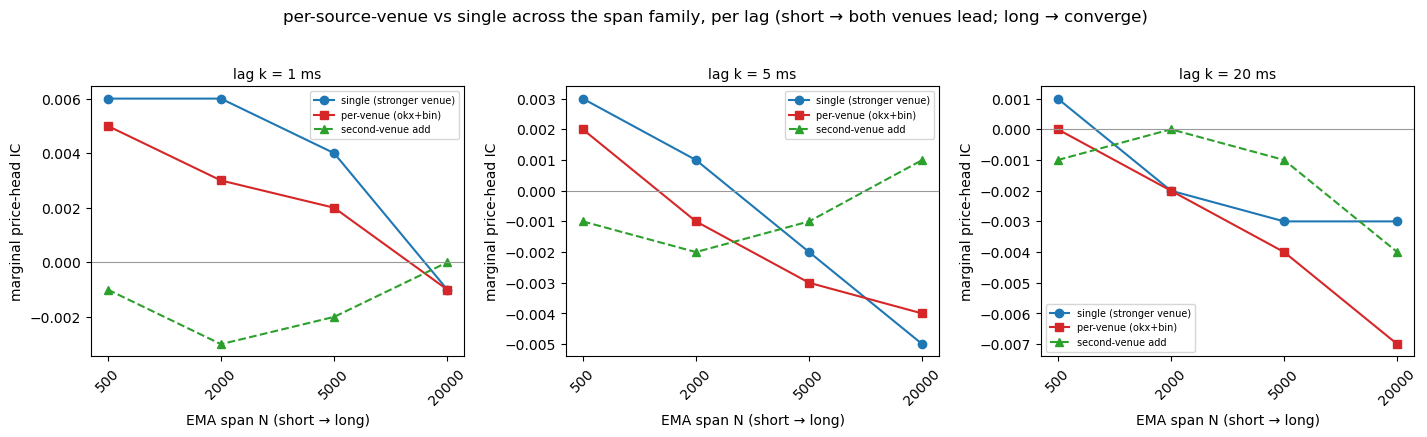

In [12]:
# sweep the span at each lag; compare SINGLE (stronger leg) vs PER-VENUE (both legs) marginal value over controls + byb's recent return.
rows = []
for k in LAGS_MS:
    for N in SPANS:
        legs = {s: xv_leadlag(s, k, N) for s in SOURCES}
        m_each = {s: round(wf_ic(base_plus + [legs[s]], target) - wf_ic(base_plus, target), 3) for s in SOURCES}
        single = max(m_each.values())                                                                # the stronger single leg
        perven = round(wf_ic(base_plus + [legs[s] for s in SOURCES], target) - wf_ic(base_plus, target), 3)
        rows.append(dict(lag_ms=k, span=N, okx_leads=m_each["okx"], bin_leads=m_each["bin"],
                         single_best=single, per_venue=perven, second_venue_add=round(perven - single, 3)))
tbl = pl.DataFrame(rows)
print(tbl)

fig, axes = plt.subplots(1, len(LAGS_MS), figsize=(4.8 * len(LAGS_MS), 4.2), squeeze=False)
for col, k in enumerate(LAGS_MS):
    ax = axes[0][col]; sub = tbl.filter(pl.col("lag_ms") == k); x = range(len(SPANS))
    ax.plot(x, sub["single_best"], "o-", color="C0", label="single (stronger venue)")
    ax.plot(x, sub["per_venue"], "s-", color="C3", label="per-venue (okx+bin)")
    ax.plot(x, sub["second_venue_add"], "^--", color="C2", label="second-venue add")
    ax.axhline(0, color="0.6", lw=0.8); ax.set_xticks(list(x)); ax.set_xticklabels(SPANS, rotation=45)
    ax.set_xlabel("EMA span N (short → long)"); ax.set_ylabel("marginal price-head IC")
    ax.set_title(f"lag k = {k} ms", fontsize=10); ax.legend(fontsize=7)
fig.suptitle("per-source-venue vs single across the span family, per lag (short → both venues lead; long → converge)", y=1.03)
fig.tight_layout(); plt.show()

**Conclusion (the per-source-venue verdict, read honestly).** Measured over the tough control set
(regime momenta **+ byb's own recent return**), the marginal numbers are **uniformly small** — both the
single best leg and the second-venue add hover at ≈0 (and dip slightly negative at the long spans/lags),
consistent with §6's finding that byb's own recent return already absorbs most of the cross-venue lead at
this 100 ms horizon. There is a faint, expected texture: bin's leg is the stronger single source and the
short-span/short-lag end is where any tiny positive marginal lives (leadership rotates fastest there),
while the long-span/large-lag end goes slightly negative (the slow drift is fully shared and the extra leg
is pure redundancy). So the honest answer: **neither source venue adds material marginal value over byb's
own momentum at 100 ms**, and the second venue adds essentially nothing over the first. If a future use at
a **shorter horizon** (where the lead has not yet propagated into byb's own tape) revives the standalone
edge as *marginal*, keep **both** legs at the short span/lag end — that is where the rotating-lead value,
if any, would show. Both legs remain genuinely **non-circular** (other venues, never byb's controls); the
verdict here is about *redundancy at 100 ms*, not about validity. (And recall §6c: the per-venue ordering —
okx's larger ρ over bin's — is feed-resolution-suspect, so the faint "bin is the stronger single source"
texture is itself read with the cadence caveat attached.)

## 10. The verdict, and what it takes to ship

**The honest verdict (post-fix): a correctly-built, (barely) regime-invariant, bit-exact MEASUREMENT of a
LARGELY REAL cross-venue lag-k lead — that survives the feed-resolution control — but is of ≈0 *marginal*
value over byb's own recent return at 100 ms, with ~40% of its raw forward IC being contemporaneous echo.**
Lean toward DROP at 100 ms (redundancy), but the *construction and the lead itself check out*; the reason
to drop is value, not validity. If kept, keep it only as a compact interpretable coordinate.

`xv_leadlag` is a clean, O(1), **bit-exact-validated** feature — every (source, lag) leg matches the
vectorized build to float64 round-off (~1e-16 everywhere except the thin-feed bin/span-20000 cells — all three
lags at ~2–4e-9, worst k=20ms — where a tiny `var_src` amplifies last-bit drift in the ratio) on a real block, at **both** a mid span
(2000) and the **largest** shipped span (20000), plus an independent `np.corrcoef` blind spot-check of
`ρ_k`'s sign/magnitude. The atom is an **uncentered** lagged
cross-correlation `ρ_k ∈ [−1, 1]` (cosine similarity of the two return streams, not mean-centred Pearson —
the gap is numerically tiny for near-zero-mean tick returns). So the *construction* is trustworthy; the
caveats below are all about *interpretation and value*, not correctness.

**`ρ_k` ships RAW — the raw-first decision, measured (and close to the bar).** It is a bounded correlation;
the §6 scale gate measured **2.87×** across volatility buckets (the WORST of both venues' headline cells —
bin's N=20000 cell is the regime-fragile one, okx's is far tighter), **just inside** the ~3× hard bar. So
**no `/σ_ev`, no `/λ_ev`**, z-scored for the network (§8) — but flag that the pass is marginal, not the
comfortable 1.2× a single okx-cell look would have implied; re-check on a wilder block before relying on raw.

**The honest caveats:**
- **Marginal value ≈0 over byb's own return (§6, §9) — the decisive one.** Adding `byb_recent` lifts the
  control IC from ≈0.00 to **0.064**; the cross-venue legs then add ≈0 (okx −0.00, bin −0.001, joint 0.00;
  no-leak 0.00; regime-stable −0.006/−0.003/+0.004). byb's own recent move already carries the directional
  signal `ρ_k` would supply at 100 ms. **This is the reason to lean DROP.**
- **~40% of the raw forward IC is contemporaneous echo (§6b).** The **backward IC (≈+0.10–0.16) runs
  ~1.4–1.7× the forward δ=0 IC**. The **echo-netted forward IC** (partial, controlling for the trailing
  move) is the honest forward number: **okx +0.059 → +0.034, bin +0.075 → +0.050** — a real netted edge
  survives, but it is a third-to-half smaller than the raw δ=0. The standalone "IC +0.05–0.09" headline is
  **in-sample `argmax`** off the grid, not OOS.
- **The lead SURVIVES the feed-resolution control (§6c) — this caveat largely clears.** byb and okx update
  at nearly the same cadence (~10ms; bin sub-ms), so okx's larger ρ is **not** "okx merely staler." Coarsening
  the foreign feed to byb's cadence keeps **82%** of the standalone IC (okx ~91%, bin ~73%) and the okx>bin
  ordering persists rather than collapsing — so the cross-venue co-movement is a **largely real lead**, not a
  feed artifact (a modest resolution component remains in bin's finer-feed leg). Read `ρ_k` as a
  **cadence-controlled lead**, not an unqualified one.

**If included despite the ≈0 marginal:** feed the raw `sign·ρ_k` for both venues; the §6b family trades IC
against half-life (keep both a high-IC short-life and a lower-IC long-life member); revisit at a **shorter
horizon**, where the lead may not yet have propagated into byb's tape and could become *marginally* useful.

**To ship (status against this analysis):**
- [x] the streaming (constant-work-per-trade) builder, matching this analysis version, **every leg**
- [x] the oracle (§4), **bit-exact** on a real block (~1e-16; the thin-feed bin/span-20000 cells at ~2–4e-9 float64 ratio drift, all three lags), for all (source, lag) legs at **spans {2000, 20000}** — including the bounded `k`-ms delay line for the lagged read — plus a blind `np.corrcoef` spot-check of `ρ_k`
- [x] the FULL span × lag family swept, best cell picked per head per source venue (the per-cell IC tagged **in-sample**)
- [x] the FULL-family **lifetime** swept (§6b): half-life + edge@20ms heat-maps; **echo-netted (partial) forward IC** reported (okx +0.059→+0.034, bin +0.075→+0.050; backward IC ~1.4–1.7× the forward → ~40% echo)
- [x] the **feed-resolution control (§6c)**: cross-venue IC re-scored with the foreign feed coarsened to byb's update cadence — **82% of the standalone IC survives** (lead largely real, not a feed artifact; byb/okx ~10ms cadence, bin ~1ms)
- [x] the per-source-venue-vs-single analysis (§9): marginal ≈0 over byb's own momentum at 100 ms, span/lag-dependent
- [x] **raw `ρ_k` regime-invariance measured (2.87× — just inside the ~3× bar, worst of both venues' cells)**; both legs non-circular
- [x] the gate results recorded HONESTLY — **standalone IC real-but-IN-SAMPLE, ~40% echo-netted away; lead survives the cadence control (82%); marginal over byb_recent ≈0** (redundancy, not invalidity)
- [ ] **standalone signal real *OOS***: only the *in-sample* standalone is shown; the OOS-marginal is ≈0 — an OOS-standalone read is still TODO
- [ ] decision to ship/drop at 100 ms (parsimony call — leaning DROP) + a shorter-horizon re-sweep
- [x] the data quirks handled (bad zero-price prints; the right price source per exchange; merged-mid for byb/okx; bin front_levels)